In [26]:
import json
from textwrap import wrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SPEC_PATH = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/head_spec_metrics.json"


def _grade(values, n_levels, method):
    s = pd.Series(values)
    if method == 'quantile':
        return pd.qcut(s, n_levels, labels=False, duplicates='drop').astype(int)
    return pd.cut(s, n_levels, labels=False).astype(int)


def load_and_grade_specificity(path=SPEC_PATH, n_levels=5, method='quantile'):
    """
    Combine Act_Eff_Dim and Act_Mag_Eff_Dim (both normalised to [0,1]) into a
    single score and bin into n_levels groups.
    Group 0 = most specific (lowest combined effective dimension).

    Returns
    -------
    groups : dict  head_name -> grade (int)
    scores : dict  head_name -> combined score (float, pre-binning)
    """
    with open(path) as f:
        data = json.load(f)

    heads       = list(data.keys())
    eff_dim     = np.array([data[h]['Act_Eff_Dim']     for h in heads], dtype=float)
    mag_eff_dim = np.array([data[h]['Act_Mag_Eff_Dim'] for h in heads], dtype=float)

    def norm(x):
        rng = x.max() - x.min()
        return (x - x.min()) / (rng if rng > 0 else 1.0)

    combined = (norm(eff_dim) + norm(mag_eff_dim)) / 2
    grades   = _grade(combined, n_levels, method)

    return (
        {h: int(grades.iloc[i]) for i, h in enumerate(heads)},
        {h: float(combined[i])  for i, h in enumerate(heads)},
    )


def load_and_grade_experiments(experiments, n_levels=5, method='quantile', metric='rank_mean'):
    """
    Load and grade task-relevance metrics across multiple experiments.

    Parameters
    ----------
    experiments : list of (label, org_path, fft_path)
        org and fft rank_means are pooled across ALL experiments before
        grading so grade levels are comparable between experiments.

    Returns
    -------
    org_groups : dict  (label, head) -> grade (int)
    fft_groups : dict  (label, head) -> grade (int)
    org_scores : dict  (label, head) -> rank_mean (float)
    fft_scores : dict  (label, head) -> rank_mean (float)
    """
    org_scores, fft_scores = {}, {}

    for label, org_path, fft_path in experiments:
        with open(org_path) as f:
            org_data = json.load(f)
        with open(fft_path) as f:
            fft_data = json.load(f)
        for h in org_data:
            org_scores[(label, h)] = org_data[h][metric]
        for h in fft_data:
            fft_scores[(label, h)] = fft_data[h][metric]

    org_keys = list(org_scores.keys())
    fft_keys = list(fft_scores.keys())

    org_grades = _grade([org_scores[k] for k in org_keys], n_levels, method)
    fft_grades = _grade([fft_scores[k] for k in fft_keys], n_levels, method)

    return (
        {k: int(org_grades.iloc[i]) for i, k in enumerate(org_keys)},
        {k: int(fft_grades.iloc[i]) for i, k in enumerate(fft_keys)},
        org_scores,
        fft_scores,
    )


def plot_specificity_vs_task_grid(
    spec_groups,
    org_groups,
    fft_groups,
    n_levels=5,
    tag=None,
    # figsize=(10, 8),
):
    """
    2-D grid where every cell (spec_group, org_group) shows the mean
    FFT task-relevance group of all (experiment, head) pairs in that cell.

    spec_groups : dict  head_name          -> grade   (shared across experiments)
    org_groups  : dict  (label, head_name) -> grade   (from load_and_grade_experiments)
    fft_groups  : dict  (label, head_name) -> grade

    X-axis : specificity group  (0 = most specific)
    Y-axis : org task-rel group (0 = least relevant)
    Cell   : mean FFT group, colour-coded red -> green
    """
    grid_sum    = np.zeros((n_levels, n_levels))
    grid_count  = np.zeros((n_levels, n_levels), dtype=int)
    point_lists = [[[] for _ in range(n_levels)] for _ in range(n_levels)]

    for (label, head), og in org_groups.items():
        if head not in spec_groups or (label, head) not in fft_groups:
            continue
        sg = spec_groups[head]
        fg = fft_groups[(label, head)]
        grid_sum[og, sg]   += fg
        grid_count[og, sg] += 1
        point_lists[og][sg].append((label, head))

    grid_mean = np.where(grid_count > 0, grid_sum / grid_count, np.nan)

    setup(1.0, aspect=1.0, base=12)
    fig, ax = plt.subplots()
    cmap = plt.cm.RdYlGn.copy()
    cmap.set_bad('0.85')

    im = ax.imshow(
        grid_mean, cmap=cmap, vmin=0, vmax=n_levels - 1,
        origin='lower', aspect='auto',
    )

    if tag == "lp":
        tag = "linear probe"
    elif tag == "fft":
        tag = "Full fine-tune"
    elif tag == "lora4":
        tag = "LoRA (rank=4)"
    elif tag == "lora16":
        tag = "LoRA (rank=16)"
    else:
        tag = "XXX"
    for og in range(n_levels):
        for sg in range(n_levels):
            n = grid_count[og, sg]
            if n > 0:
                ax.text(sg, og, f'{grid_mean[og, sg]:.2f}\n(n={n})',
                        ha='center', va='center', fontsize=8, fontweight='bold')
            else:
                ax.text(sg, og, '–', ha='center', va='center',
                        fontsize=10, color='0.55')

    ax.set_xticks(range(n_levels))
    ax.set_xticklabels([f'{i}' for i in range(n_levels)])
    ax.set_yticks(range(n_levels))
    ax.set_yticklabels([f'{i}' for i in range(n_levels)])
    ax.set_xlabel('Specificity group')
    ax.set_ylabel('New task-relevance group')
    # ax.set_title(
    #     f'{tag} \n'
    #     f'Mean head relevance group per (specificity × New task-relevance) cell'
    #     f'\n({n_levels} levels, {grid_count.sum()} total points, '
    #     f'colour: 0=red → {n_levels-1}=green)'
    # )
    ax.set_title(
        f'{tag} \n'
        f'\n({n_levels} levels, {grid_count.sum()} total points, '
        f'colour: 0=red → {n_levels-1}=green)'
    )
    plt.colorbar(im, ax=ax, label=f'Mean {tag} group  [0 – {n_levels-1}]')
    # plt.tight_layout()

    save_folder = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/plots/notebook"
    plt.savefig(f"{save_folder}/specificity_vs_{tag.replace(' ', '_')}_grid.png", dpi=300)

    plt.show()

    return grid_mean, point_lists


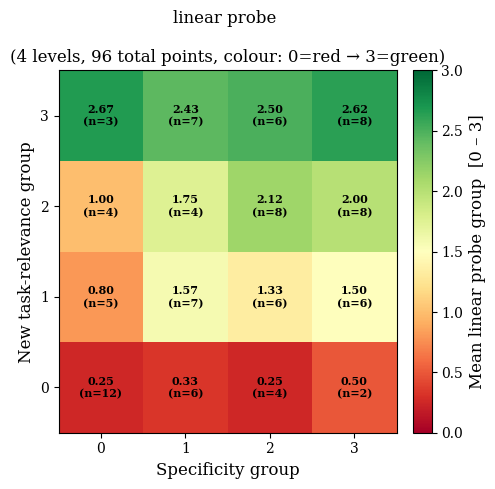

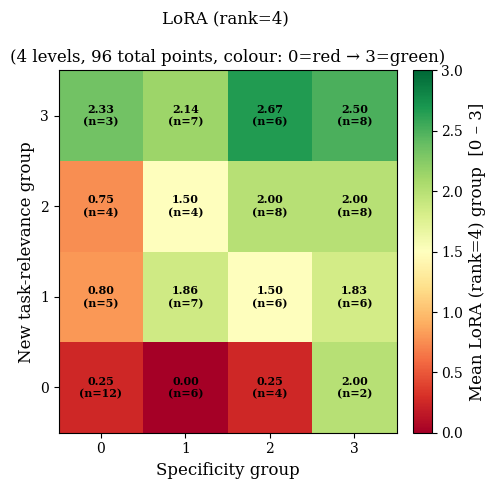

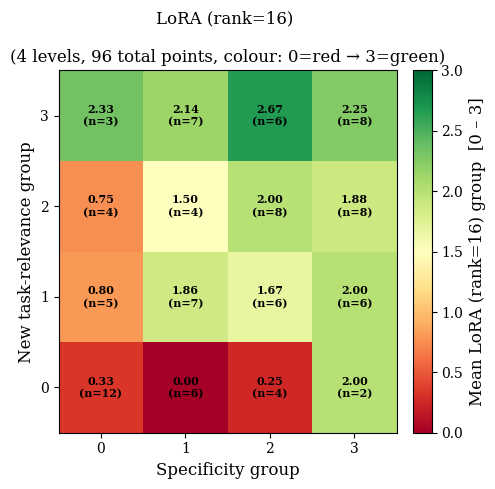

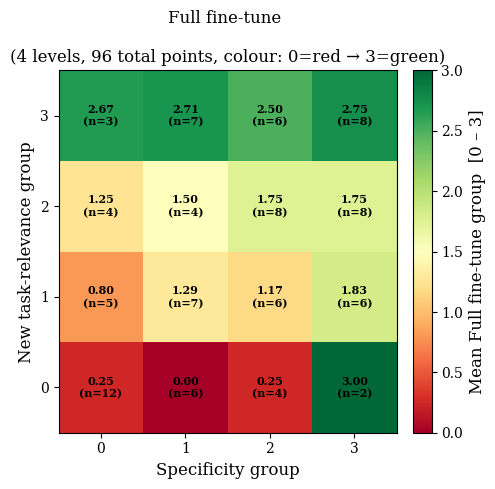

In [ ]:
SPEC_PATH     = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/head_spec_metrics.json"
ORG_CLIP_PATH = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_org_clip.json"
sun_org       = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/sun/new_task_rel_org_clip.json"

tags = ["lp", "lora4", "lora16", "fft"]
tags = ["lora4", "lora16", "fft"]
for tag in tags:
    FFT_PATH      = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_" + tag + ".json"
    sun_fft       = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/sun/new_task_rel_" + tag + ".json"

    N = 4  # number of levels; change to 6 etc.

    # Add more experiments as (label, org_path, fft_path)
    experiments = [
        ('imagenet', ORG_CLIP_PATH, FFT_PATH),
        ('sun',      sun_org,       sun_fft),
    ]

    spec_groups, spec_scores = load_and_grade_specificity(n_levels=N)
    org_groups, fft_groups, org_scores, fft_scores = load_and_grade_experiments(experiments, n_levels=N, metric='top_k_mean')

    grid_mean, point_lists = plot_specificity_vs_task_grid(
        spec_groups, org_groups, fft_groups, n_levels=N, tag=tag
    )


### part2

In [ ]:
pth1 = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_fft.json"
pth2 = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_lora16.json"
pth3 = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_lora4.json"
pth4 = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_lp.json"

fft = json.load(open(pth1, "r"))
lora16 = json.load(open(pth2, "r"))
lora4 = json.load(open(pth3, "r"))
lp = json.load(open(pth4, "r"))

data = [fft, lora16, lora4, lp]

rank_means = []
top_k_means = []
for d in data:
    for head, data in d.items():
        rank_means.append(data['rank_mean'])
        top_k_means.append(data['top_k_mean'])

# make both same range and add them together
rank_means = np.array(rank_means)
top_k_means = np.array(top_k_means)
rank_means = (rank_means - rank_means.min()) / (rank_means.max() - rank_means.min())
top_k_means = (top_k_means - top_k_means.min()) / (top_k_means.max() - top_k_means.min())

joint_scores = rank_means + top_k_means

In [46]:
import numpy as np
import matplotlib.pyplot as plt

data = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_merged.json", "r"))
rank_means = []
top_k_means = []
for head, change in data.items():
    rank_means.append(change['fft']['rank_mean'])
    rank_means.append(change['lora16']['rank_mean'])
    rank_means.append(change['lora4']['rank_mean'])
    rank_means.append(change['lp']['rank_mean'])

    top_k_means.append(change['fft']['top_k_mean'])
    top_k_means.append(change['lora16']['top_k_mean'])
    top_k_means.append(change['lora4']['top_k_mean'])
    top_k_means.append(change['lp']['top_k_mean'])

rank_means = np.array(rank_means)
top_k_means = np.array(top_k_means)

min_rank_mean = np.min(rank_means)
min_top_k_mean = np.min(top_k_means)
max_rank_mean = np.max(rank_means)
max_top_k_mean = np.max(top_k_means)

rank_means = (rank_means - min_rank_mean) / (max_rank_mean - min_rank_mean)
top_k_means = (top_k_means - min_top_k_mean) / (max_top_k_mean - min_top_k_mean)

joint_scores = rank_means + top_k_means

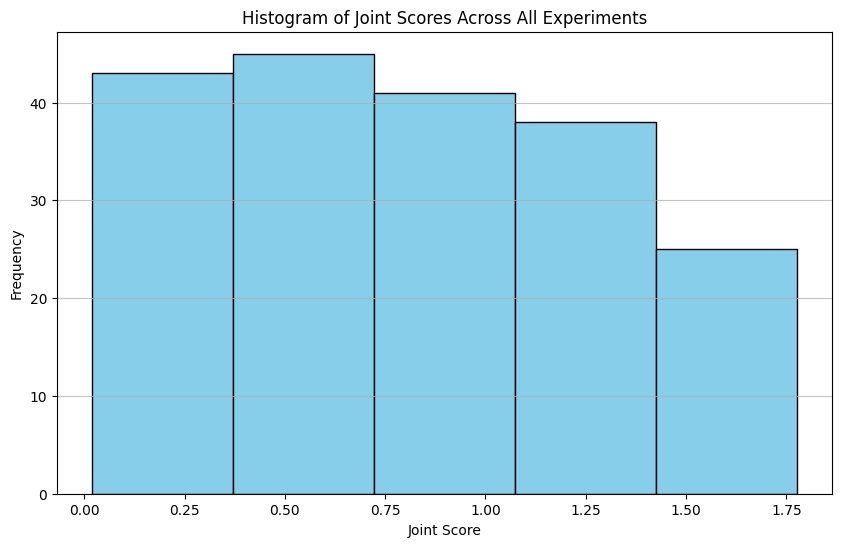

In [47]:
#histogram of rank_means
plt.figure(figsize=(10, 6))
plt.hist(joint_scores, bins=5, color='skyblue', edgecolor='black')
plt.title('Histogram of Joint Scores Across All Experiments')
plt.xlabel('Joint Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

In [59]:
f1 = "specialized"
f2 = "Ignored"
f3 = "different_function"
f4 = "same_function"

for head, change in data.items():
    for key, value in change.items():
        if value['category'] == f4:
            rm = value['rank_mean']
            tk = value['top_k_mean']
            rm = (rm - min_rank_mean) / (max_rank_mean - min_rank_mean)
            tk = (tk - min_top_k_mean) / (max_top_k_mean - min_top_k_mean)
            joint_score = rm + tk

        # print(f"Head: {head}, Method: {key}, Joint Score: {joint_score:.4f}, Rank Mean: {rm:.4f}, Top K Mean: {tk:.4f}")
            print(head, joint_score)
        # if joint_score < 0.5:
        #     value['category'] = f2

Layer 9 Head 2 1.296041366569578
Layer 9 Head 8 0.8595019344583367
Layer 9 Head 8 0.9626423744302532
Layer 10 Head 0 0.9543181642103994
Layer 10 Head 0 0.9800914312343142
Layer 10 Head 0 1.0979112447217683
Layer 10 Head 2 1.1889953569797964
Layer 10 Head 2 1.1735604822010366
Layer 10 Head 2 1.3109680350889197
Layer 10 Head 2 1.7312043198302445
Layer 10 Head 4 1.334656403907639
Layer 10 Head 4 1.3281387262798066
Layer 10 Head 4 1.3933120238629313
Layer 10 Head 6 0.6140260148573039
Layer 10 Head 6 0.6178195800625939
Layer 10 Head 6 0.5455608751434367
Layer 10 Head 6 0.7321554784176434
Layer 10 Head 10 1.4684056870120883
Layer 10 Head 10 1.4405734569716118
Layer 10 Head 10 1.3879463083075196
Layer 10 Head 10 1.509383053374098
Layer 11 Head 3 1.7590787741603104
Layer 11 Head 3 1.7323532284209342
Layer 11 Head 5 1.7362815984977575
Layer 11 Head 5 1.7377577712103767
Layer 11 Head 5 1.2755861108835997
Layer 11 Head 5 1.5991228865142078
Layer 11 Head 6 1.3169016945786658
Layer 11 Head 6 1.3589

In [58]:
json.dump(data, open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_merged.json", "w"), indent=4)

In [ ]:
changes_pth = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_fft.json"
changes = json.load(open(changes_pth, "r"))

rank_means = []
top_k_means = []
for head, change in changes.items():
    rank_means.append(change['rank_mean'])
    top_k_means.append(change['top_k_mean'])

rm_mean = np.mean(rank_means)
tk_mean = np.mean(top_k_means)
rm_min = np.min(rank_means)
tk_min = np.min(top_k_means)
rm_max = np.max(rank_means)
tk_max = np.max(top_k_means)

f1 = "Specialized"
f2 = "Ignored"
f3 = "different_function"
f4 = "same_function"

for head, change in changes.items():
    # print(change['category'])
    if change['category'] == f4:
        # print(head, (change['top_k_mean'] - top_k_means.min()) / (top_k_means.max() - top_k_means.min()))
        # print(head, (change['rank_mean'] - rank_means.min()) / (rank_means.max() - rank_means.min()))
        rm = (change['rank_mean'] - rm_min) / (rm_max - rm_min)
        tk = (change['top_k_mean'] - tk_min) / (tk_max - tk_min)
        joint = rm + tk
        print(head, joint)

Layer 9 Head 2 1.345037486453343
Layer 9 Head 8 0.9871428088418446
Layer 10 Head 2 1.806229087492322
Layer 10 Head 6 0.7338571668715899
Layer 10 Head 10 1.5682091146303283
Layer 11 Head 3 0.41841800564033993
Layer 11 Head 5 1.6563563253943705
Layer 11 Head 6 1.4892602448459098
Layer 11 Head 8 1.1387268542312405
Layer 11 Head 10 1.595841653936016


In [1]:
import json

# Load files
with open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_lora_lp.json", "r") as f:
    first_json = json.load(f)

with open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_fft.json", "r") as f:
    second_json = json.load(f)

result = {}

for head, values in first_json.items():
    result[head] = {}

    # Process lora4, lora16, lp
    for key in ["lora4", "lora16", "lp"]:
        if key in values:
            result[head][key] = {
                "category": values[key][0],  # first element of list
                "rank_mean": 0,
                "top_k_mean": 0
            }

    # Add fft from second JSON
    fft_category = second_json.get(head, {}).get("category", "")

    result[head]["fft"] = {
        "category": fft_category,
        "rank_mean": 0,
        "top_k_mean": 0
    }

# Save output
with open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_merged.json", "w") as f:
    json.dump(result, f, indent=4)

print("Merged JSON saved to merged.json")

Merged JSON saved to merged.json


In [12]:
org = "different_function"
new = "Changed function"

org2 = "Became useless"
new2 = "Ignored"

org3 = "same_function"
new3 = "Same function"

data = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_merged.json", "r"))

In [38]:
for head, change in data.items():
    print(change)
    for key, value in change.items():
        # print(value)
        # print(value['category'])
        if value['category'] == "Specialized":
            value['category'] = "specialized"

{'lora4': {'category': 'different_function', 'rank_mean': 0.3477233946323395, 'top_k_mean': 0.9915913343429565}, 'lora16': {'category': 'different_function', 'rank_mean': 0.3247021436691284, 'top_k_mean': 0.929444432258606}, 'lp': {'category': 'different_function', 'rank_mean': 0.5483404994010925, 'top_k_mean': 1.6968307495117188}, 'fft': {'category': 'different_function', 'rank_mean': 0.4633830189704895, 'top_k_mean': 1.9517478942871094}}
{'lora4': {'category': 'different_function', 'rank_mean': 0.22185108065605164, 'top_k_mean': 0.7636311650276184}, 'lora16': {'category': 'different_function', 'rank_mean': 0.21417021751403809, 'top_k_mean': 0.6851957440376282}, 'lp': {'category': 'different_function', 'rank_mean': 0.2381063997745514, 'top_k_mean': 0.7729026675224304}, 'fft': {'category': 'Ignored', 'rank_mean': 0.17763829231262207, 'top_k_mean': 0.8206457495689392}}
{'lora4': {'category': 'different_function', 'rank_mean': 0.21702128648757935, 'top_k_mean': 0.6412724256515503}, 'lora

In [39]:
with open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_merged.json", "w") as f:
    json.dump(data, f, indent=4)

In [14]:
for head, change in data.items():
    print(change)
    for key, value in change.items():
        print(value)

{'lora4': {'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}, 'lora16': {'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}, 'lp': {'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}, 'fft': {'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}}
{'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}
{'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}
{'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}
{'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}
{'lora4': {'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}, 'lora16': {'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}, 'lp': {'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}, 'fft': {'category': 'Ignored', 'rank_mean': 0, 'top_k_mean': 0}}
{'category': 'different_function', 'rank_mean': 0, 'top_k_mean': 0}
{'category': 'different_function', 'rank_mean': 0, 't

In [17]:
pth1 = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_fft.json"
pth2 = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_lora16.json"
pth3 = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_lora4.json"
pth4 = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_lp.json"

data1 = json.load(open(pth1, "r"))
data2 = json.load(open(pth2, "r"))
data3 = json.load(open(pth3, "r"))
data4 = json.load(open(pth4, "r"))

data = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_merged.json", "r"))

In [22]:
for head, change in data.items():
    data[head]['lora4']['rank_mean'] = data3[head]['rank_mean']
    data[head]['lora16']['rank_mean'] = data2[head]['rank_mean']
    data[head]['lp']['rank_mean'] = data4[head]['rank_mean']
    data[head]['fft']['rank_mean'] = data1[head]['rank_mean']

    data[head]['lora4']['top_k_mean'] = data3[head]['top_k_mean']
    data[head]['lora16']['top_k_mean'] = data2[head]['top_k_mean']
    data[head]['lp']['top_k_mean'] = data4[head]['top_k_mean']
    data[head]['fft']['top_k_mean'] = data1[head]['top_k_mean']

In [24]:
with open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_merged.json", "w") as f:
    json.dump(data, f, indent=4)

# hjfg

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

In [5]:
pth_imgnet = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k"
pth_sun = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/sun"
pth_text = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/text"

datasets = [pth_imgnet, pth_sun, pth_text]

methods = ["fft", "lora16", "lora4"]

base_names = ["act_change_metrics_", "change_metrics_", "new_task_rel_"]

selected_metrics_dict = {}

selected_metrics_dict["act_change_metrics_"] = ["CKA_Linear", "Subspace_Alignment"]
selected_metrics_dict["change_metrics_"] = ["qk_relative_frobenius", "qk_weighted_subspace_overlap", "ov_relative_frobenius", "ov_weighted_subspace_overlap"]
selected_metrics_dict["new_task_rel_"] = ["rank_mean", "top_k_mean"]
selected_metrics_dict["spec"] = ["Act_Eff_Dim", "Act_Mag_Eff_Dim"]

selected_metrics_dict["new_task_rel_org_clip"] = ["rank_mean", "top_k_mean"]

head_spec = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/head_spec_metrics.json", "r"))

In [192]:
selected_metrics_dict

{'act_change_metrics_': ['CKA_Linear', 'Subspace_Alignment'],
 'change_metrics_': ['qk_relative_frobenius',
  'qk_weighted_subspace_overlap',
  'ov_relative_frobenius',
  'ov_weighted_subspace_overlap'],
 'new_task_rel_': ['rank_mean', 'top_k_mean'],
 'spec': ['Act_Eff_Dim', 'Act_Mag_Eff_Dim'],
 'new_task_rel_org_clip': ['rank_mean', 'top_k_mean']}

In [6]:
def create_compact_dict(selected_metrics_dict, datasets, methods, base_names, head_spec):
    compact_dict = {}

    # rename org_clip metrics so they don't collide with new_task_rel_
    org_clip_rename = {"rank_mean": "rank_mean_before",
                       "top_k_mean": "top_k_mean_before"}

    # initialize keys
    for key, metrics in selected_metrics_dict.items():
        for metric in metrics:
            if key == "new_task_rel_org_clip":
                metric = org_clip_rename[metric]
            compact_dict[metric] = []          # no inner char loop

    for pth in datasets:
        for method in methods:
            for base_name in base_names:
                file_path = f"{pth}/{base_name}{method}.json"
                data = json.load(open(file_path, "r"))

                for head, metrics in data.items():
                    for metric in selected_metrics_dict[base_name]:
                        compact_dict[metric].append(metrics[metric])

            ntr = json.load(open(f"{pth}/new_task_rel_org_clip.json", "r"))

            for head, metrics in head_spec.items():
                for metric in selected_metrics_dict["spec"]:
                    compact_dict[metric].append(metrics[metric])

            for head, metrics in ntr.items():
                for metric in selected_metrics_dict["new_task_rel_org_clip"]:
                    compact_dict[org_clip_rename[metric]].append(metrics[metric])

    return compact_dict

In [94]:
compact_dict_filtered = {}

filt_key = "top_k_mean_before"

spec_mean = np.mean(compact_dict[filt_key])
# filter values that are more than 2 std devs away from the mean
spec_std = np.std(compact_dict[filt_key])

# find indices of values that are within 2 std devs of the mean
indices = np.where((compact_dict[filt_key] < spec_mean))[0]

for key, value in compact_dict.items():
    compact_dict_filtered[key] = [value[i] for i in indices]

print(f"Filtered {filt_key}: {len(compact_dict[filt_key])} -> {len(compact_dict_filtered[filt_key])}")

Filtered top_k_mean_before: 432 -> 240


CKA_Linear: 432
Subspace_Alignment: 432
qk_relative_frobenius: 432
qk_weighted_subspace_overlap: 432
ov_relative_frobenius: 432
ov_weighted_subspace_overlap: 432
rank_mean: 432
top_k_mean: 432
Act_Eff_Dim: 432
Act_Mag_Eff_Dim: 432
rank_mean_before: 432
top_k_mean_before: 432


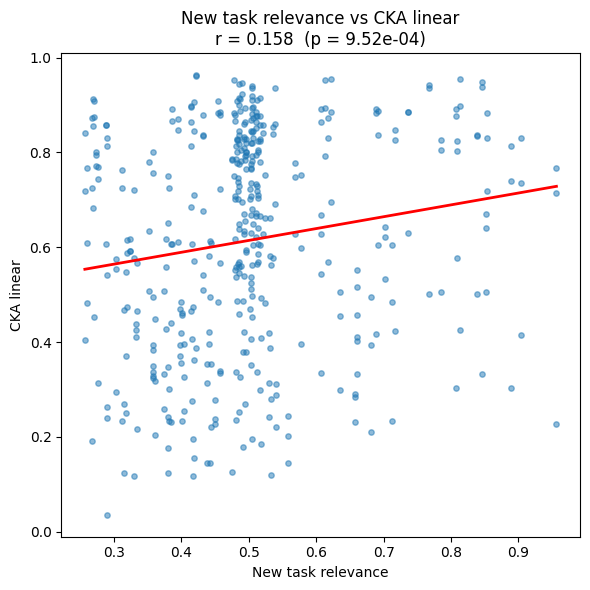

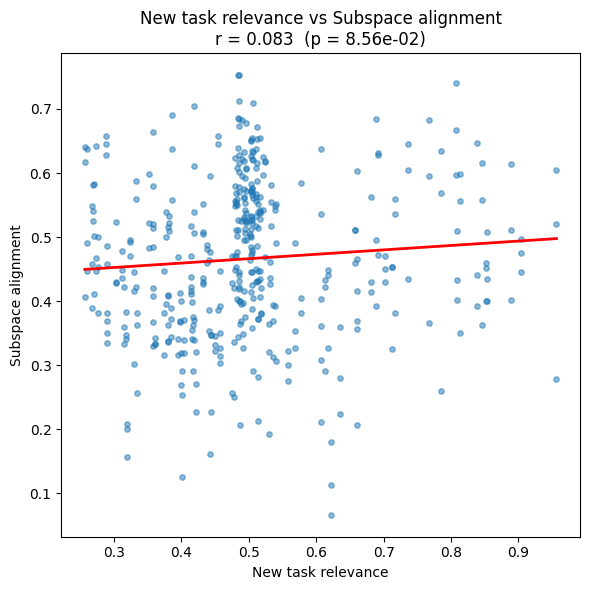

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_correlation(data, key_x, key_y, x_axis=None, y_axis=None):
    x = data[key_x]
    y = data[key_y]

    r, p = pearsonr(x, y)

    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, alpha=0.5, s=15)

    # best-fit line
    import numpy as np
    m, b = np.polyfit(x, y, 1)
    xs = np.array([min(x), max(x)])
    plt.plot(xs, m * xs + b, color="red", lw=2)

    if x_axis:
        plt.xlabel(x_axis)
    else:
        plt.xlabel(key_x)

    if y_axis:
        plt.ylabel(y_axis)
    else:
        plt.ylabel(key_y)

    plt.title(f"{x_axis} vs {y_axis}\nr = {r:.3f}  (p = {p:.2e})")
    plt.tight_layout()
    

    save_folder = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/plots/notebook"

    # save the plot
    plt.savefig(f"{save_folder}/{key_x}_vs_{key_y}.png", dpi=300)
    plt.show()


# example
methods = ["fft", "lora16", "lora4"]
datasets_sam = [datasets[i] for i in [0, 1, 2]]
# methods = ["fft"]
compact_dict = create_compact_dict(selected_metrics_dict, datasets_sam, methods, base_names, head_spec)
for key, value in compact_dict.items():
    print(f"{key}: {len(value)}")

x_axis = "New task relevance"
# y_axis = "QK forbenius distance"
# plot_correlation(compact_dict, "top_k_mean_before", "qk_weighted_subspace_overlap", x_axis=x_axis, y_axis=y_axis)
# y_axis = "QK weighted subspace overlap"
# plot_correlation(compact_dict, "top_k_mean_before", "qk_relative_frobenius", x_axis=x_axis, y_axis=y_axis)

y_axis = "CKA linear"
plot_correlation(compact_dict, "rank_mean_before", "CKA_Linear", x_axis=x_axis, y_axis=y_axis)
y_axis = "Subspace alignment"
plot_correlation(compact_dict, "rank_mean_before", "Subspace_Alignment", x_axis=x_axis, y_axis=y_axis)

In [104]:
list(compact_dict.keys())

['CKA_Linear',
 'Subspace_Alignment',
 'qk_relative_frobenius',
 'qk_weighted_subspace_overlap',
 'ov_relative_frobenius',
 'ov_weighted_subspace_overlap',
 'rank_mean',
 'Act_Eff_Dim',
 'Act_Mag_Eff_Dim',
 'top_k_mean_before']

CKA_Linear: 144
Subspace_Alignment: 144
qk_relative_frobenius: 144
qk_weighted_subspace_overlap: 144
ov_relative_frobenius: 144
ov_weighted_subspace_overlap: 144
rank_mean: 144
top_k_mean: 144
Act_Eff_Dim: 144
Act_Mag_Eff_Dim: 144
rank_mean_before: 144
top_k_mean_before: 144


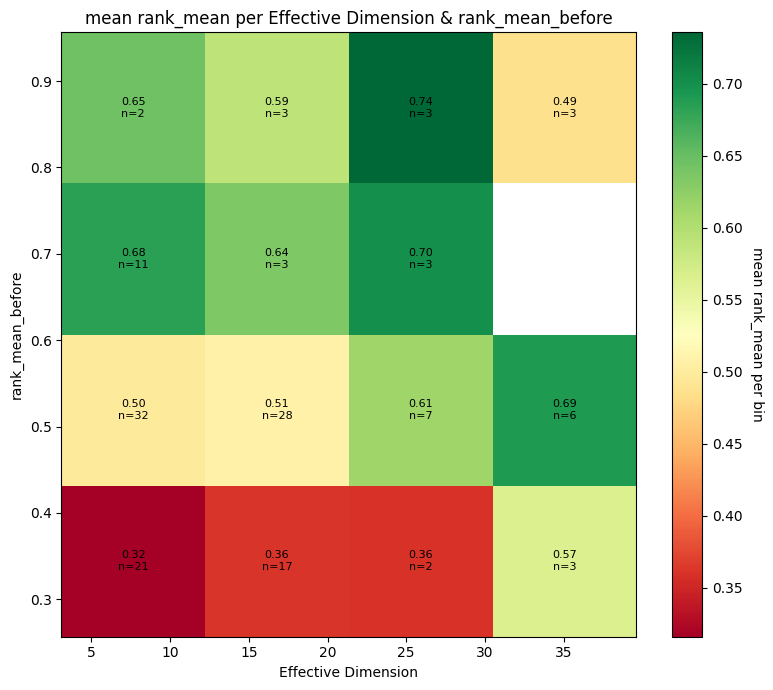

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

def plot_binned_avg(data, key_x, key_y, key_z, bins=10, naming=None):
    x = np.array(data[key_x])
    y = np.array(data[key_y])
    z = np.array(data[key_z])

    # average of z and count of entries in each (x, y) bin
    stat, x_edges, y_edges, _ = binned_statistic_2d(
        x, y, z, statistic="mean", bins=bins
    )
    counts, _, _, _ = binned_statistic_2d(
        x, y, z, statistic="count", bins=bins
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    # red (low) -> green (high)
    mesh = ax.pcolormesh(x_edges, y_edges, stat.T, cmap="RdYlGn", shading="flat")
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(f"mean {naming.get(key_z, key_z) if naming else key_z} per bin", rotation=270, labelpad=15)

    # annotate each cell with the average value and entry count
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2
    for i in range(stat.shape[0]):       # x bins
        for j in range(stat.shape[1]):   # y bins
            val = stat[i, j]
            n = int(counts[i, j])
            if not np.isnan(val):
                ax.text(
                    x_centers[i], y_centers[j], f"{val:.2f}\nn={n}",
                    ha="center", va="center", color="black", fontsize=8,
                )

    if naming:
        ax.set_xlabel(naming.get(key_x, key_x))
        ax.set_ylabel(naming.get(key_y, key_y))
        ax.set_title(f"mean {naming.get(key_z, key_z)} per {naming.get(key_x, key_x)} & {naming.get(key_y, key_y)}")
    else:
        ax.set_xlabel(key_x)
        ax.set_ylabel(key_y)
        ax.set_title(f"mean  {naming.get(key_z, key_z)}  per  {naming.get(key_x, key_x)} & {naming.get(key_y, key_y)}")
    plt.tight_layout()
    

    save_folder = "/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/plots/notebook"
    plt.savefig(f"{save_folder}/{key_z}_vs_{key_x}_and_{key_y}.png", dpi=300)
    plt.show()

naming = {
    "Act_Eff_Dim": "Effective Dimension",
    "top_k_mean_before": "New Task Relevance",
    "qk_relative_frobenius": "QK Frobenius",
    "qk_weighted_subspace_overlap": "QK Weighted Subspace Overlap",
    "ov_relative_frobenius": "OV Frobenius",
    "ov_weighted_subspace_overlap": "OV Weighted Subspace Overlap",
    "CKA_Linear": "CKA Linear",
    "Subspace_Alignment": "Subspace Alignment",

}
# example
# plot_binned_avg(compact_dict, "Act_Eff_Dim", "top_k_mean_before", "CKA_Linear", bins=3, naming=naming)
# plot_binned_avg(compact_dict, "Act_Eff_Dim", "top_k_mean_before", "Subspace_Alignment", bins=3, naming=naming)

# plot_binned_avg(compact_dict, "Act_Eff_Dim", "top_k_mean_before", "top_k_mean", bins=3, naming=naming)

methods = ["fft", "lora16", "lora4"]
datasets_sam = [datasets[i] for i in [0, 1, 2]]
methods = ["fft"]
compact_dict = create_compact_dict(selected_metrics_dict, datasets_sam, methods, base_names, head_spec)
for key, value in compact_dict.items():
    print(f"{key}: {len(value)}")

zz = "rank_mean"
plot_binned_avg(compact_dict, "Act_Eff_Dim", f"{zz}_before", f"{zz}", bins=4, naming=naming)

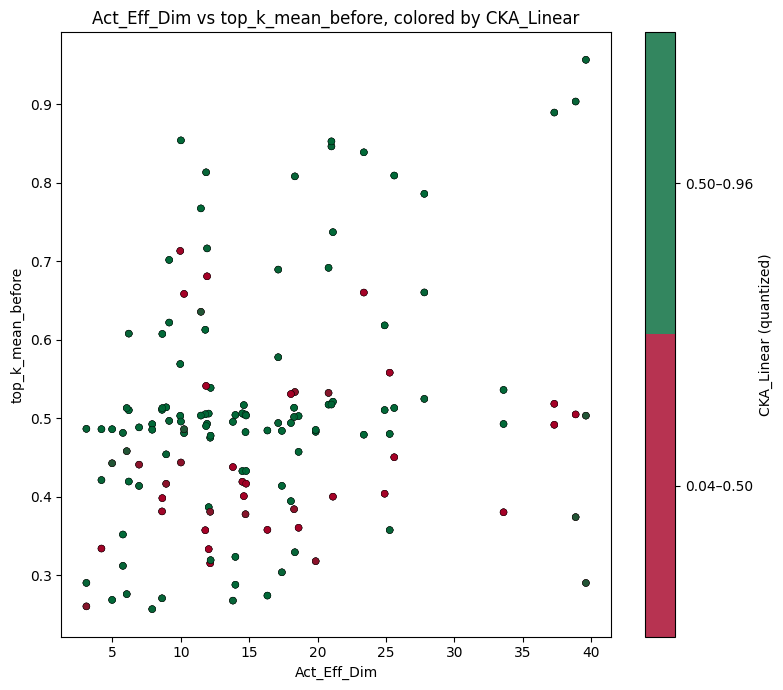

In [112]:
import numpy as np
import matplotlib.pyplot as plt

def plot_scatter_quantized(data, key_x, key_y, key_z, n_levels=5):
    x = np.array(data[key_x])
    y = np.array(data[key_y])
    z = np.array(data[key_z])

    # quantize z into n_levels groups (equal-width bins)
    z_edges = np.linspace(z.min(), z.max(), n_levels + 1)
    z_bin = np.clip(np.digitize(z, z_edges) - 1, 0, n_levels - 1)

    fig, ax = plt.subplots(figsize=(8, 7))
    cmap = plt.get_cmap("RdYlGn", n_levels)  # red (low) -> green (high)

    sc = ax.scatter(x, y, c=z_bin, cmap=cmap, vmin=-0.5, vmax=n_levels - 0.5,
                    s=25, alpha=0.8, edgecolors="k", linewidths=0.3)

    # colorbar with the value range of each group
    cbar = fig.colorbar(sc, ax=ax, ticks=range(n_levels))
    cbar.set_label(f"{key_z} (quantized)")
    cbar.set_ticklabels(
        [f"{z_edges[k]:.2f}–{z_edges[k+1]:.2f}" for k in range(n_levels)]
    )

    ax.set_xlabel(key_x)
    ax.set_ylabel(key_y)
    ax.set_title(f"{key_x} vs {key_y}, colored by {key_z}")
    plt.tight_layout()
    plt.show()

plot_scatter_quantized(compact_dict, "Act_Eff_Dim", "top_k_mean_before", "CKA_Linear", n_levels=2)

# uhsuhf

In [12]:
import matplotlib.pyplot as plt

TEXTWIDTH_PT = 345.0
TEXTWIDTH_IN = TEXTWIDTH_PT / 72.27

def setup(c, aspect=0.65, base=12):
    r"""                                       # raw string -> no \i warning
    c      : scale used in \includegraphics[width=c\textwidth]
    aspect : height / width of the whole figure
    base   : pt size text should appear as in the PDF
    """
    w = c * TEXTWIDTH_IN
    plt.rcParams.update({
        'figure.figsize'  : (w, w * aspect),
        'font.family'     : 'serif',
        'font.size'       : base,
        'axes.titlesize'  : base,
        'axes.labelsize'  : base,
        'xtick.labelsize' : base - 2,
        'ytick.labelsize' : base - 2,
        'legend.fontsize' : base - 2,
        'figure.constrained_layout.use': True,
    })

import textwrap

def wrap(s, width=30):           # width = characters per line
    return textwrap.fill(s, width)

In [5]:
import json, re
from pathlib import Path
import pandas as pd

BASE = Path("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real")

# ---- pick which metric is "specificity" (x) and "new-task relevance" (y) ----
SPEC_METRIC = "Act_Eff_Dim"   # from head_spec_metrics.json
RELE_METRIC = "top_k_mean"    # from <ds>/new_task_rel_org_clip.json  (in [0,1])
# other spec options: Act_Eff_Dim, Text_Eff_Dim, Act_Entropy_bits, Group_Entropy_bits, Act_Mag_Eff_Dim
# other rele options: rank_consistency, median_disc, top_k_mean, gini

# dataset -> (folder, semantic-shift file)
DATASETS = {
    "text":       ("text",       "semantic_shift_simple.json"),
    "sun":        ("sun",        "semantic_shift_simple.json"),
    "imagenet1k": ("imagenet1k", "changes_merged.json"),
}

GROUPS = ["ignored", "repurposed", "same_function", "specialized"]
GROUP_COLORS = {
    "ignored":       "#9e9e9e",
    "repurposed":    "#1f77b4",
    "same_function": "#2ca02c",
    "specialized":   "#d62728",
}

# ---------- normalizers ----------
_HEAD_RE = re.compile(r"Layer\s*(\d+)\s*Head\s*(\d+)|L(\d+)\.H(\d+)", re.I)
def head_key(s):
    m = _HEAD_RE.search(str(s))
    if not m:
        return None
    return (int(m.group(1)), int(m.group(2))) if m.group(1) is not None \
        else (int(m.group(3)), int(m.group(4)))

def clean_cat(s):                       # "ignored(0.70)" -> "ignored"
    if not isinstance(s, str):
        return None
    return re.sub(r"\(.*?\)", "", s).strip().lower()

def norm_style(s):                      # "FFT"->"fft", "LoRA16"->"lora16", "LP"->"lp"
    return str(s).strip().lower()

# ---------- loaders ----------
def load_metric(path, metric):          # {(layer,head): value}
    raw = json.load(open(path))
    return {head_key(k): v.get(metric) for k, v in raw.items() if head_key(k)}

def load_shift(path):                   # {(layer,head): {style: category}}
    raw = json.load(open(path))
    out = {}
    for hk, styles in raw.items():
        hkey = head_key(hk)
        if hkey is None:
            continue
        d = {}
        for st, val in styles.items():
            cat = clean_cat(val["category"]) if isinstance(val, dict) else clean_cat(val)
            if cat:
                d[norm_style(st)] = cat
        out[hkey] = d
    return out

# ---------- build tidy long dataframe ----------
spec = load_metric(BASE / "head_spec_metrics.json", SPEC_METRIC)

rows = []
for ds, (folder, fname) in DATASETS.items():
    shift = load_shift(BASE / folder / fname)
    rele  = load_metric(BASE / folder / "new_task_rel_org_clip.json", RELE_METRIC)
    for hkey, style_map in shift.items():
        s, r = spec.get(hkey), rele.get(hkey)
        if s is None or r is None:
            continue
        for style, group in style_map.items():
            rows.append(dict(dataset=ds, layer=hkey[0], head=hkey[1],
                             style=style, group=group, spec=s, rele=r))

df = pd.DataFrame(rows)
print(df.shape)
# NOTE: use df["style"] not df.style ( .style is the pandas Styler property )
print("datasets:", sorted(df["dataset"].unique()),
      "| styles:", sorted(df["style"].unique()),
      "| groups:", sorted(df["group"].unique()))
df.head()

(576, 7)
datasets: ['imagenet1k', 'sun', 'text'] | styles: ['fft', 'lora16', 'lora4', 'lp'] | groups: ['ignored', 'repurposed', 'same_function', 'specialized']


,dataset,layer,head,style,group,spec,rele
0,text,8,0,fft,repurposed,6.95,0.384761
1,text,8,0,lora4,repurposed,6.95,0.384761
2,text,8,0,lora16,repurposed,6.95,0.384761
3,text,8,0,lp,repurposed,6.95,0.384761
4,text,8,1,fft,repurposed,5.77,0.438913


In [2]:
len(df)

576

/tmp/ipykernel_2796214/358966713.py:55: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_2796214/358966713.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


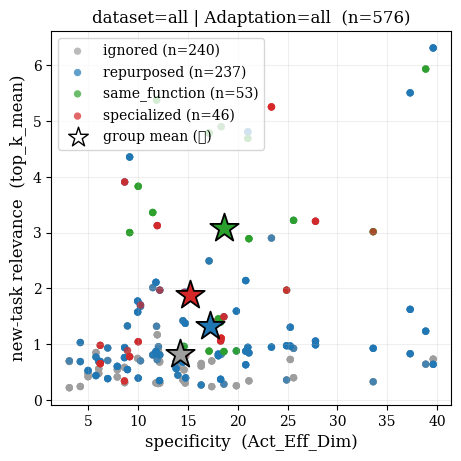

/tmp/ipykernel_2796214/358966713.py:61: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_2796214/358966713.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_2796214/358966713.py:62: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_spec_vs_rele.png", dpi=300)


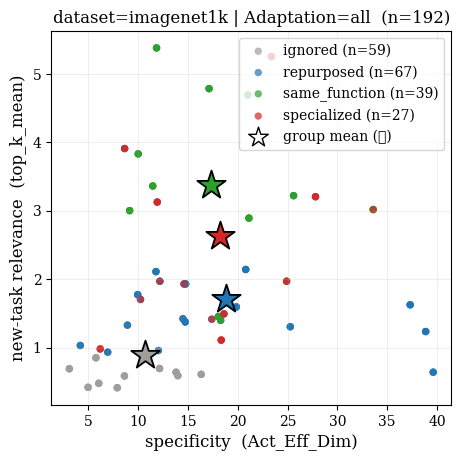

/tmp/ipykernel_2796214/358966713.py:77: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout();
/tmp/ipykernel_2796214/358966713.py:77: UserWarning: The figure layout has changed to tight
  plt.tight_layout();
/tmp/ipykernel_2796214/358966713.py:78: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_fft_spec_vs_rele.png", dpi=300)


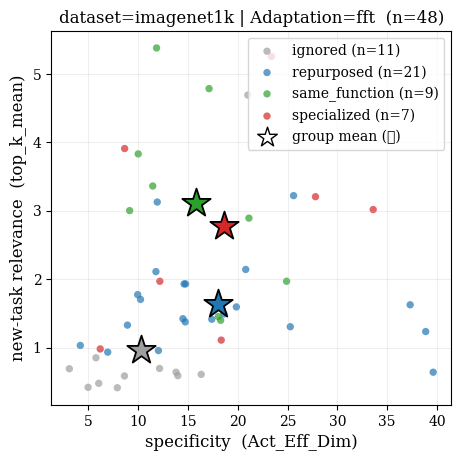

/tmp/ipykernel_2796214/358966713.py:82: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_2796214/358966713.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_2796214/358966713.py:83: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_lora16_spec_vs_rele.png", dpi=300)


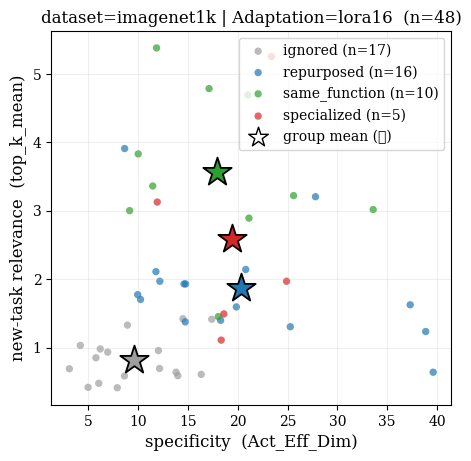

/tmp/ipykernel_2796214/358966713.py:87: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_2796214/358966713.py:87: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_2796214/358966713.py:88: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_lora4_spec_vs_rele.png", dpi=300)


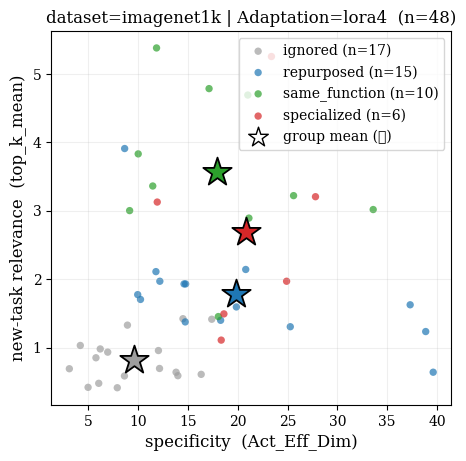

In [11]:
def scatter_spec_vs_rele(df, dataset=None, style=None, ax=None, title=None,
                         alpha=0.7, show_means=True):
    """
    dataset: None=pool all, str, or list of datasets ('text','sun','imagenet1k')
    style:   None=pool all, str, or list of styles    ('fft','lp','lora4','lora16')
    Points are colored by the 4 semantic-shift groups.
    show_means: draw a star at each group's (mean spec, mean rele).
    """
    sub = df
    if dataset is not None:
        ds = [dataset] if isinstance(dataset, str) else list(dataset)
        sub = sub[sub["dataset"].isin(ds)]
    if style is not None:
        sty = [style] if isinstance(style, str) else list(style)
        sub = sub[sub["style"].isin([s.lower() for s in sty])]
    
    setup(1.0, aspect=1.0, base=12)
    if ax is None:
        _, ax = plt.subplots()

    for g in GROUPS:
        pts = sub[sub["group"] == g]
        ax.scatter(pts["spec"], pts["rele"], s=28, alpha=alpha,
                   color=GROUP_COLORS[g], edgecolor="none",
                   label=f"{g} (n={len(pts)})")

    # ---- per-group averages, drawn as stars on top ----
    if show_means:
        for g in GROUPS:
            pts = sub[sub["group"] == g]
            if len(pts):
                ax.scatter(pts["spec"].mean(), pts["rele"].mean(),
                           marker="*", s=460, color=GROUP_COLORS[g],
                           edgecolor="black", linewidth=1.3, zorder=5)
        # single legend proxy for the star marker
        ax.scatter([], [], marker="*", s=220, color="white",
                   edgecolor="black", linewidth=1.0, label="group mean (★)")

    ax.set_xlabel(f"specificity  ({SPEC_METRIC})")
    ax.set_ylabel(f"new-task relevance  ({RELE_METRIC})")
    if title is None:
        d = "all" if dataset is None else (dataset if isinstance(dataset, str) else "+".join(dataset))
        st = "all" if style is None else (style if isinstance(style, str) else "+".join(style))
        title = f"dataset={d} | Adaptation={st}  (n={len(sub)})"
    ax.set_title(title)
    # ax.legend(fontsize=8, framealpha=0.9)
    ax.legend()
    ax.grid(alpha=0.2)
    return ax

# ---- examples ----

# 1) pool everything
scatter_spec_vs_rele(df)
plt.tight_layout()
# plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/all_spec_vs_rele.png", dpi=300)
plt.show()

# 2) per dataset
scatter_spec_vs_rele(df, dataset="imagenet1k")
plt.tight_layout()
plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_spec_vs_rele.png", dpi=300)
plt.show()

# scatter_spec_vs_rele(df, dataset="sun")
# plt.tight_layout(); plt.show()

# scatter_spec_vs_rele(df, dataset="text")
# plt.tight_layout(); plt.show()

# # 3) per adaptation style (pooled across datasets)
# scatter_spec_vs_rele(df, style="lora16")
# plt.tight_layout(); plt.show()

# 4) both at once
scatter_spec_vs_rele(df, dataset="imagenet1k", style="fft")
plt.tight_layout();
plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_fft_spec_vs_rele.png", dpi=300)
plt.show()

scatter_spec_vs_rele(df, dataset="imagenet1k", style="lora16")
plt.tight_layout()
plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_lora16_spec_vs_rele.png", dpi=300)
plt.show()

scatter_spec_vs_rele(df, dataset="imagenet1k", style="lora4")
plt.tight_layout()
plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_lora4_spec_vs_rele.png", dpi=300)
plt.show()

### weight change vs representation change

In [32]:
import matplotlib.pyplot as plt

TEXTWIDTH_PT = 345.0
TEXTWIDTH_IN = TEXTWIDTH_PT / 72.27

def setup(c, aspect=0.65, base=12):
    r"""                                       # raw string -> no \i warning
    c      : scale used in \includegraphics[width=c\textwidth]
    aspect : height / width of the whole figure
    base   : pt size text should appear as in the PDF
    """
    w = c * TEXTWIDTH_IN
    plt.rcParams.update({
        'figure.figsize'  : (w, w * aspect),
        'font.family'     : 'serif',
        'font.size'       : base,
        'axes.titlesize'  : base,
        'axes.labelsize'  : base,
        'xtick.labelsize' : base - 2,
        'ytick.labelsize' : base - 2,
        'legend.fontsize' : base - 2,
        'figure.constrained_layout.use': True,
    })

import textwrap

def wrap(s, width=30):           # width = characters per line
    return textwrap.fill(s, width)

In [33]:
# ===== weight-change vs representation-change =====
# act_change_metrics_<style>.json  -> representation (activation) change
# change_metrics_<style>.json      -> weight change (qk_* and ov_* variants)
# LP is excluded here (no weight/representation-change data for it).
# Reuses head_key / clean_cat / norm_style / load_shift / DATASETS / BASE / GROUPS / GROUP_COLORS
# from the spec-vs-relevance cells above, so run those first.

WR_STYLES = ["fft", "lora4", "lora16"]

# pick ONE metric per axis (swap these to whatever you want to inspect)
WEIGHT_METRIC = "ov_relative_frobenius"   # x : from change_metrics_<style>.json
REP_METRIC    = "CKA_Linear"              # y : from act_change_metrics_<style>.json
# weight options (each has a qk_* and an ov_* form): relative_frobenius, sv_correlation,
#   energy_ratio_change, spectral_distance, mean_cos_angle, weighted_subspace_overlap,
#   effective_rank_change, new_direction_fraction, within_subspace_fraction
# rep options: CKA_Linear, Subspace_Alignment, Principal_Angle_Deg, Eff_Dim_Change,
#   Total_Var_Ratio, Spectral_Entropy_Change, Centroid_Shift_Cosine, Centroid_Shift_RelNorm

def _load_kv(path, metric):                 # {(layer,head): value}
    raw = json.load(open(path))
    return {head_key(k): v.get(metric) for k, v in raw.items() if head_key(k)}

def create_wr_df(WEIGHT_METRIC=WEIGHT_METRIC, REP_METRIC=REP_METRIC):
    rows = []
    for ds, (folder, fname) in DATASETS.items():
        shift = load_shift(BASE / folder / fname)          # {(L,H): {style: group}}
        for style in WR_STYLES:
            wmet = _load_kv(BASE / folder / f"change_metrics_{style}.json",     WEIGHT_METRIC)
            rmet = _load_kv(BASE / folder / f"act_change_metrics_{style}.json", REP_METRIC)
            for hkey, style_map in shift.items():
                group = style_map.get(style)               # semantic group for this style (LP skipped)
                if group is None:
                    continue
                w, r = wmet.get(hkey), rmet.get(hkey)
                if w is None or r is None:
                    continue
                rows.append(dict(dataset=ds, layer=hkey[0], head=hkey[1],
                                style=style, group=group, weight=w, rep=r))

    df_wr = pd.DataFrame(rows)
    print(df_wr.shape)
    print("datasets:", sorted(df_wr["dataset"].unique()),
        "| styles:", sorted(df_wr["style"].unique()),
        "| groups:", sorted(df_wr["group"].unique()))
    df_wr.head()
    return df_wr

(432, 7)
datasets: ['imagenet1k', 'sun', 'text'] | styles: ['fft', 'lora16', 'lora4'] | groups: ['ignored', 'repurposed', 'same_function', 'specialized']


/tmp/ipykernel_2796214/312817843.py:60: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout();
/tmp/ipykernel_2796214/312817843.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout();
/tmp/ipykernel_2796214/312817843.py:61: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_weight_vs_rep_all.png", dpi=300)


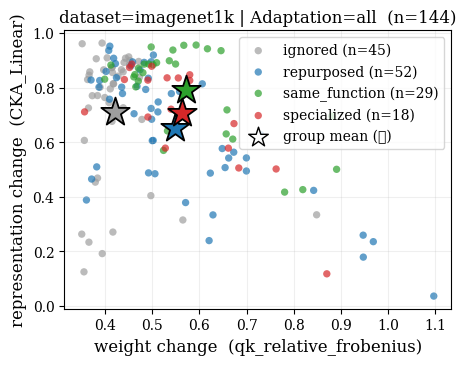

/tmp/ipykernel_2796214/312817843.py:65: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout();
/tmp/ipykernel_2796214/312817843.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout();
/tmp/ipykernel_2796214/312817843.py:66: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_weight_vs_rep_fft.png", dpi=300)


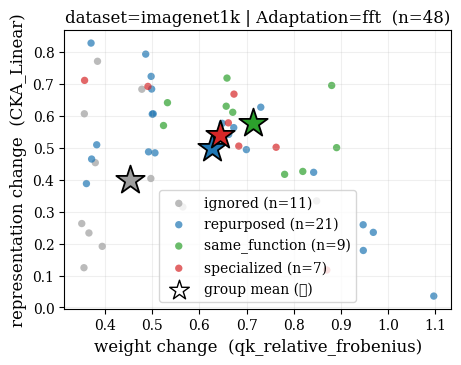

/tmp/ipykernel_2796214/312817843.py:70: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout();
/tmp/ipykernel_2796214/312817843.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout();
/tmp/ipykernel_2796214/312817843.py:71: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_weight_vs_rep_lora16.png", dpi=300)


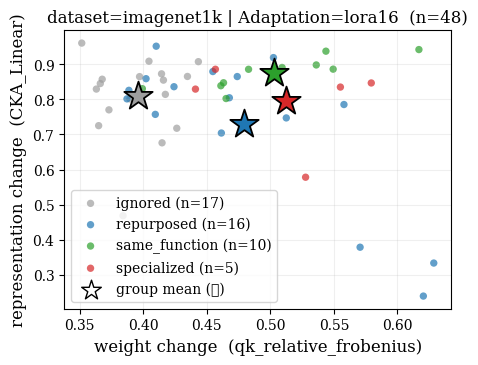

/tmp/ipykernel_2796214/312817843.py:75: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout();
/tmp/ipykernel_2796214/312817843.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout();
/tmp/ipykernel_2796214/312817843.py:76: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_weight_vs_rep_lora4.png", dpi=300)


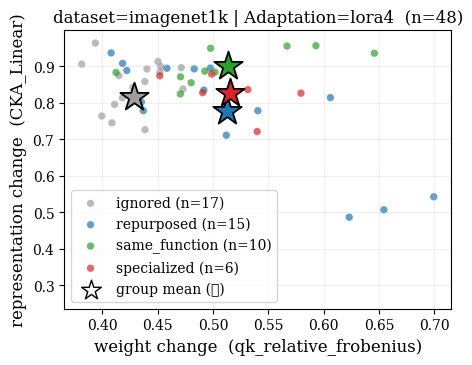

In [40]:
def scatter_weight_vs_rep(df, dataset=None, style=None, ax=None, title=None,
                          alpha=0.7, show_means=True):
    """
    x = weight change (WEIGHT_METRIC), y = representation change (REP_METRIC).
    dataset: None=pool all, str, or list ('text','sun','imagenet1k')
    style:   None=pool all, str, or list ('fft','lora4','lora16')   # LP not available
    Colored by the 4 semantic-shift groups; stars = per-group means.
    """
    sub = df
    if dataset is not None:
        ds = [dataset] if isinstance(dataset, str) else list(dataset)
        sub = sub[sub["dataset"].isin(ds)]
    if style is not None:
        sty = [style] if isinstance(style, str) else list(style)
        sub = sub[sub["style"].isin([s.lower() for s in sty])]

    setup(1.0, aspect=0.8, base=12)
    if ax is None:
        _, ax = plt.subplots()

    for g in GROUPS:
        pts = sub[sub["group"] == g]
        ax.scatter(pts["weight"], pts["rep"], s=28, alpha=alpha,
                   color=GROUP_COLORS[g], edgecolor="none",
                   label=f"{g} (n={len(pts)})")

    # ---- per-group averages, drawn as stars on top ----
    if show_means:
        for g in GROUPS:
            pts = sub[sub["group"] == g]
            if len(pts):
                ax.scatter(pts["weight"].mean(), pts["rep"].mean(),
                           marker="*", s=460, color=GROUP_COLORS[g],
                           edgecolor="black", linewidth=1.3, zorder=5)
        ax.scatter([], [], marker="*", s=220, color="white",
                   edgecolor="black", linewidth=1.0, label="group mean (★)")

    ax.set_xlabel(f"weight change  ({WEIGHT_METRIC})")
    ax.set_ylabel(f"representation change  ({REP_METRIC})")
    if title is None:
        d = "all" if dataset is None else (dataset if isinstance(dataset, str) else "+".join(dataset))
        st = "all" if style is None else (style if isinstance(style, str) else "+".join(style))
        title = f"dataset={d} | Adaptation={st}  (n={len(sub)})"
    ax.set_title(title)
    # ax.legend(fontsize=8, framealpha=0.9)
    ax.legend()
    ax.grid(alpha=0.2)
    return ax

# ---- examples ----
WEIGHT_METRIC = "qk_relative_frobenius"   # x : from change_metrics_<style>.json
REP_METRIC    = "CKA_Linear"
df_wr = create_wr_df(WEIGHT_METRIC=WEIGHT_METRIC, REP_METRIC=REP_METRIC)
# 1) pool everything
# scatter_weight_vs_rep(df_wr)
# plt.tight_layout(); plt.show()

# 2) per dataset
scatter_weight_vs_rep(df_wr, dataset="imagenet1k")
plt.tight_layout();
plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_weight_vs_rep_all.png", dpi=300)
plt.show()

scatter_weight_vs_rep(df_wr, dataset="imagenet1k", style="fft")
plt.tight_layout();
plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_weight_vs_rep_fft.png", dpi=300)
plt.show()

scatter_weight_vs_rep(df_wr, dataset="imagenet1k", style="lora16")
plt.tight_layout();
plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_weight_vs_rep_lora16.png", dpi=300)
plt.show()

scatter_weight_vs_rep(df_wr, dataset="imagenet1k", style="lora4")
plt.tight_layout();
plt.savefig("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/plots/imagenet1k_weight_vs_rep_lora4.png", dpi=300)
plt.show()

# scatter_weight_vs_rep(df_wr, dataset="sun")
# plt.tight_layout(); plt.show()

# scatter_weight_vs_rep(df_wr, dataset="text")
# plt.tight_layout(); plt.show()

# # 3) per adaptation method (pooled across datasets)
# scatter_weight_vs_rep(df_wr, style="fft")
# plt.tight_layout(); plt.show()

# scatter_weight_vs_rep(df_wr, style="lora16")
# plt.tight_layout(); plt.show()

# scatter_weight_vs_rep(df_wr, style="lora4")
# plt.tight_layout(); plt.show()

# # # 4) both at once
# # scatter_weight_vs_rep(df_wr, dataset="sun", style="fft")
# # plt.tight_layout(); plt.show()

### grid: spec x new-task-relevance, one panel per change metric (auto weight/representation)

In [29]:
# ===== combined grid: builder (any number of change metrics) =====
# Each (dataset, style, head) is one point. x = specificity, y = new-task relevance.
# You pass a LIST of change metrics; each is auto-classified as "weight" (found in
# change_metrics_<style>.json) or "representation" (found in act_change_metrics_<style>.json).
# Reuses head_key / load_metric / DATASETS / BASE from the cells above -> run those first.
import numpy as np

WR_STYLES = ["fft", "lora4", "lora16"]      # LP has no weight/representation change

def _change_metric_keys(sample_folder="text", sample_style="fft"):
    """Return (weight_keys, representation_keys) available in the change JSONs."""
    wf = json.load(open(BASE / sample_folder / f"change_metrics_{sample_style}.json"))
    af = json.load(open(BASE / sample_folder / f"act_change_metrics_{sample_style}.json"))
    return set(next(iter(wf.values())).keys()), set(next(iter(af.values())).keys())

def classify_change_metric(metric):
    wkeys, akeys = _change_metric_keys()
    if metric in wkeys:
        return "weight"
    if metric in akeys:
        return "representation"
    raise KeyError(f"{metric!r} not found in weight (change_metrics) or "
                   f"representation (act_change_metrics) files")

def build_grid_df(spec_metric, rele_metric, change_metrics,
                  datasets=DATASETS, styles=WR_STYLES):
    """Assemble per-(dataset, style, head) points for the binned grid plots.
      spec_metric    -> head_spec_metrics.json        (x-axis)
      rele_metric    -> new_task_rel_org_clip.json     (y-axis)
      change_metrics -> str or list of change-metric keys; each becomes its own panel.
                        Kind (weight / representation) is detected from the JSON it lives in.
    Metric names + kinds are stored on df.attrs so the plot can label each panel.
    """
    if isinstance(change_metrics, str):
        change_metrics = [change_metrics]
    kinds = {m: classify_change_metric(m) for m in change_metrics}
    file_pat = {"weight": "change_metrics", "representation": "act_change_metrics"}

    spec = load_metric(BASE / "head_spec_metrics.json", spec_metric)
    rows = []
    for ds, (folder, fname) in datasets.items():
        rele = load_metric(BASE / folder / "new_task_rel_org_clip.json", rele_metric)
        for style in styles:
            metvals = {m: load_metric(BASE / folder / f"{file_pat[kinds[m]]}_{style}.json", m)
                       for m in change_metrics}
            for hkey in spec:                       # the 48 heads
                s, rl = spec.get(hkey), rele.get(hkey)
                if s is None or rl is None:
                    continue
                vals = {m: metvals[m].get(hkey) for m in change_metrics}
                if any(v is None for v in vals.values()):
                    continue
                row = dict(dataset=ds, style=style, layer=hkey[0], head=hkey[1], spec=s, rele=rl)
                row.update(vals)
                rows.append(row)

    df = pd.DataFrame(rows)
    df.attrs.update(spec_metric=spec_metric, rele_metric=rele_metric,
                    change_metrics=list(change_metrics), metric_kinds=kinds)
    return df

In [30]:
# --- choose metrics here, rerun this small cell to swap. change_metrics can be any length ---
df_grid = build_grid_df(
    spec_metric    = "wSCI_Score",            # x-axis: head specificity
    rele_metric    = "rank_mean",             # y-axis: new-task relevance
    change_metrics = [
        "ov_relative_frobenius",   # weight
        "qk_relative_frobenius",   # weight
        "CKA_Linear",              # representation
        "Subspace_Alignment",      # representation
    ],
)
print(df_grid.shape, "|", {k: df_grid.attrs[k] for k in ("spec_metric", "rele_metric")})
print("metric kinds:", df_grid.attrs["metric_kinds"])
df_grid.head()

(432, 10) | {'spec_metric': 'wSCI_Score', 'rele_metric': 'rank_mean'}
metric kinds: {'ov_relative_frobenius': 'weight', 'qk_relative_frobenius': 'weight', 'CKA_Linear': 'representation', 'Subspace_Alignment': 'representation'}


,dataset,style,layer,head,spec,rele,ov_relative_frobenius,qk_relative_frobenius,CKA_Linear,Subspace_Alignment
0,text,fft,8,0,0.4651,0.440798,0.1375,0.1226,0.4209,0.4649
1,text,fft,8,1,0.4846,0.351808,0.1324,0.1307,0.7799,0.4823
2,text,fft,8,2,0.5430,0.260266,0.1621,0.1384,0.7682,0.4477
3,text,fft,8,3,0.5165,0.381223,0.1334,0.1307,0.7250,0.5214
4,text,fft,8,4,0.6275,0.357713,0.1742,0.1356,0.3489,0.5208


In [31]:
from matplotlib.colors import Normalize

def grid_change_metrics(df, dataset=None, style=None, nbins=5, ncols=2,
                        cmap="RdYlGn", panel_size=(7.0, 6.0), annotate=True):
    """
    x = specificity, y = new-task relevance, binned into nbins x nbins equal-width cells.
    One panel per change metric in df.attrs["change_metrics"]; cell color = MEAN of that
    metric over its points (RED = low, GREEN = high); cell text = "<mean>\n(n=<count>)".
    Panel title shows the metric key and its kind (weight / representation change).
    dataset / style: None=pool all, str, or list.
    """
    metrics = list(df.attrs.get("change_metrics", []))
    kinds   = df.attrs.get("metric_kinds", {})
    spec_m  = df.attrs.get("spec_metric", "spec")
    rele_m  = df.attrs.get("rele_metric", "rele")

    sub = df
    if dataset is not None:
        ds = [dataset] if isinstance(dataset, str) else list(dataset)
        sub = sub[sub["dataset"].isin(ds)]
    if style is not None:
        sty = [style] if isinstance(style, str) else list(style)
        sub = sub[sub["style"].isin([s.lower() for s in sty])]
    sub = sub.dropna(subset=["spec", "rele"] + metrics)

    x = sub["spec"].to_numpy()
    y = sub["rele"].to_numpy()
    # shared bin edges -> every panel uses the same grid (only the color value differs)
    xe = np.linspace(x.min(), x.max(), nbins + 1)
    ye = np.linspace(y.min(), y.max(), nbins + 1)
    counts, _, _ = np.histogram2d(x, y, bins=[xe, ye])
    xc = (xe[:-1] + xe[1:]) / 2
    yc = (ye[:-1] + ye[1:]) / 2

    n = len(metrics)
    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(panel_size[0] * ncols, panel_size[1] * nrows),
                             squeeze=False)
    axes_flat = axes.ravel()
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad("#f0f0f0")                                # empty cells = grey

    for idx, metric in enumerate(metrics):
        ax = axes_flat[idx]
        sums, _, _ = np.histogram2d(x, y, bins=[xe, ye], weights=sub[metric].to_numpy())
        with np.errstate(invalid="ignore"):
            means = np.where(counts > 0, sums / counts, np.nan)   # [x, y]

        finite = np.isfinite(means)
        vmin = float(np.nanmin(means)) if finite.any() else 0.0
        vmax = float(np.nanmax(means)) if finite.any() else 1.0
        if vmax == vmin:
            vmax = vmin + 1e-9
        norm = Normalize(vmin=vmin, vmax=vmax)

        pc = ax.pcolormesh(xe, ye, np.ma.masked_invalid(means.T),  # .T -> rows=y, cols=x
                           cmap=cmap_obj, norm=norm, shading="flat")
        cb = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label("mean per cell  (red = low, green = high)")

        if annotate and finite.any():
            for i in range(nbins):          # x index
                for j in range(nbins):      # y index
                    nC = int(counts[i, j])
                    if nC == 0:
                        continue
                    m = means[i, j]
                    r_, g_, b_, _ = cmap_obj(norm(m))            # cell color -> luminance
                    lum = 0.299 * r_ + 0.587 * g_ + 0.114 * b_
                    tc = "black" if lum > 0.55 else "white"
                    ax.text(xc[i], yc[j], f"{m:.2f}\n(n={nC})",
                            ha="center", va="center", fontsize=8, color=tc)

        ax.set_xlabel(f"specificity ({spec_m})")
        ax.set_ylabel(f"new-task relevance ({rele_m})")
        ax.set_title(f"{metric}\n({kinds.get(metric, '?')} change)")

    for ax in axes_flat[n:]:                 # hide any unused panels
        ax.axis("off")

    d  = "all" if dataset is None else (dataset if isinstance(dataset, str) else "+".join(dataset))
    st = "all" if style   is None else (style   if isinstance(style,   str) else "+".join(style))
    fig.suptitle(f"dataset={d} | style={st} | bins={nbins} | n={len(sub)}",
                 y=1.005, fontsize=13)
    fig.tight_layout()
    return fig, axes

(432, 10) | {'spec_metric': 'wSCI_Score', 'rele_metric': 'rank_mean'}
metric kinds: {'ov_relative_frobenius': 'weight', 'qk_relative_frobenius': 'weight', 'CKA_Linear': 'representation', 'Subspace_Alignment': 'representation'}


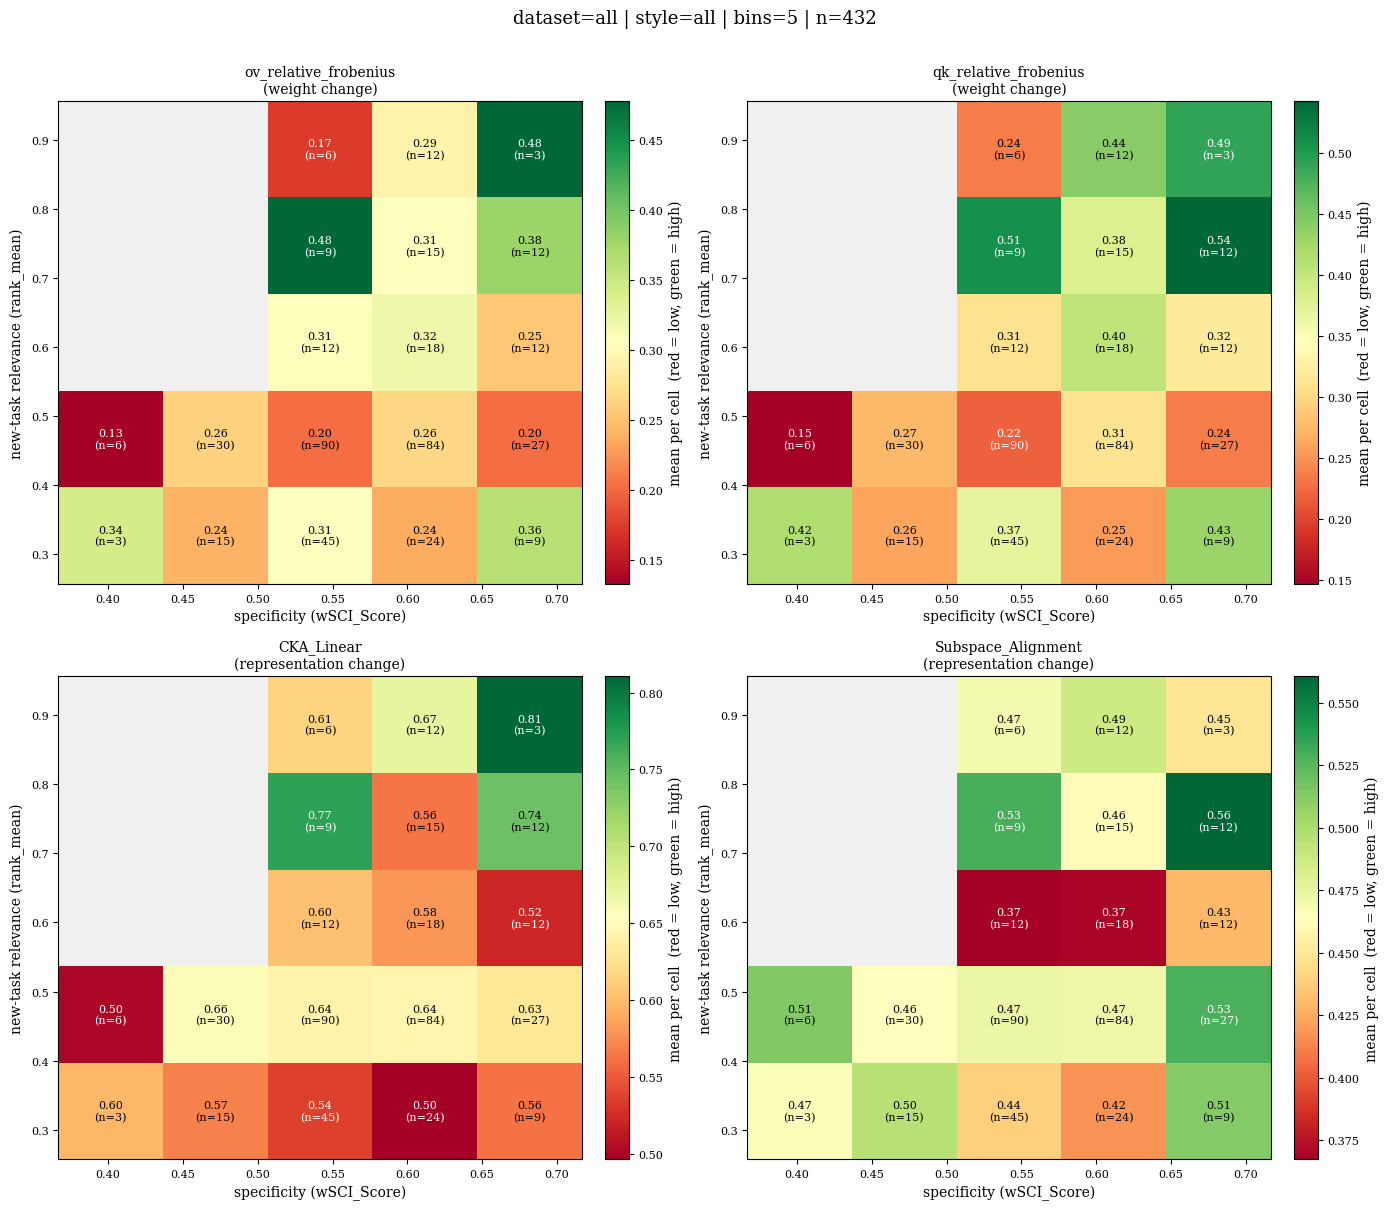

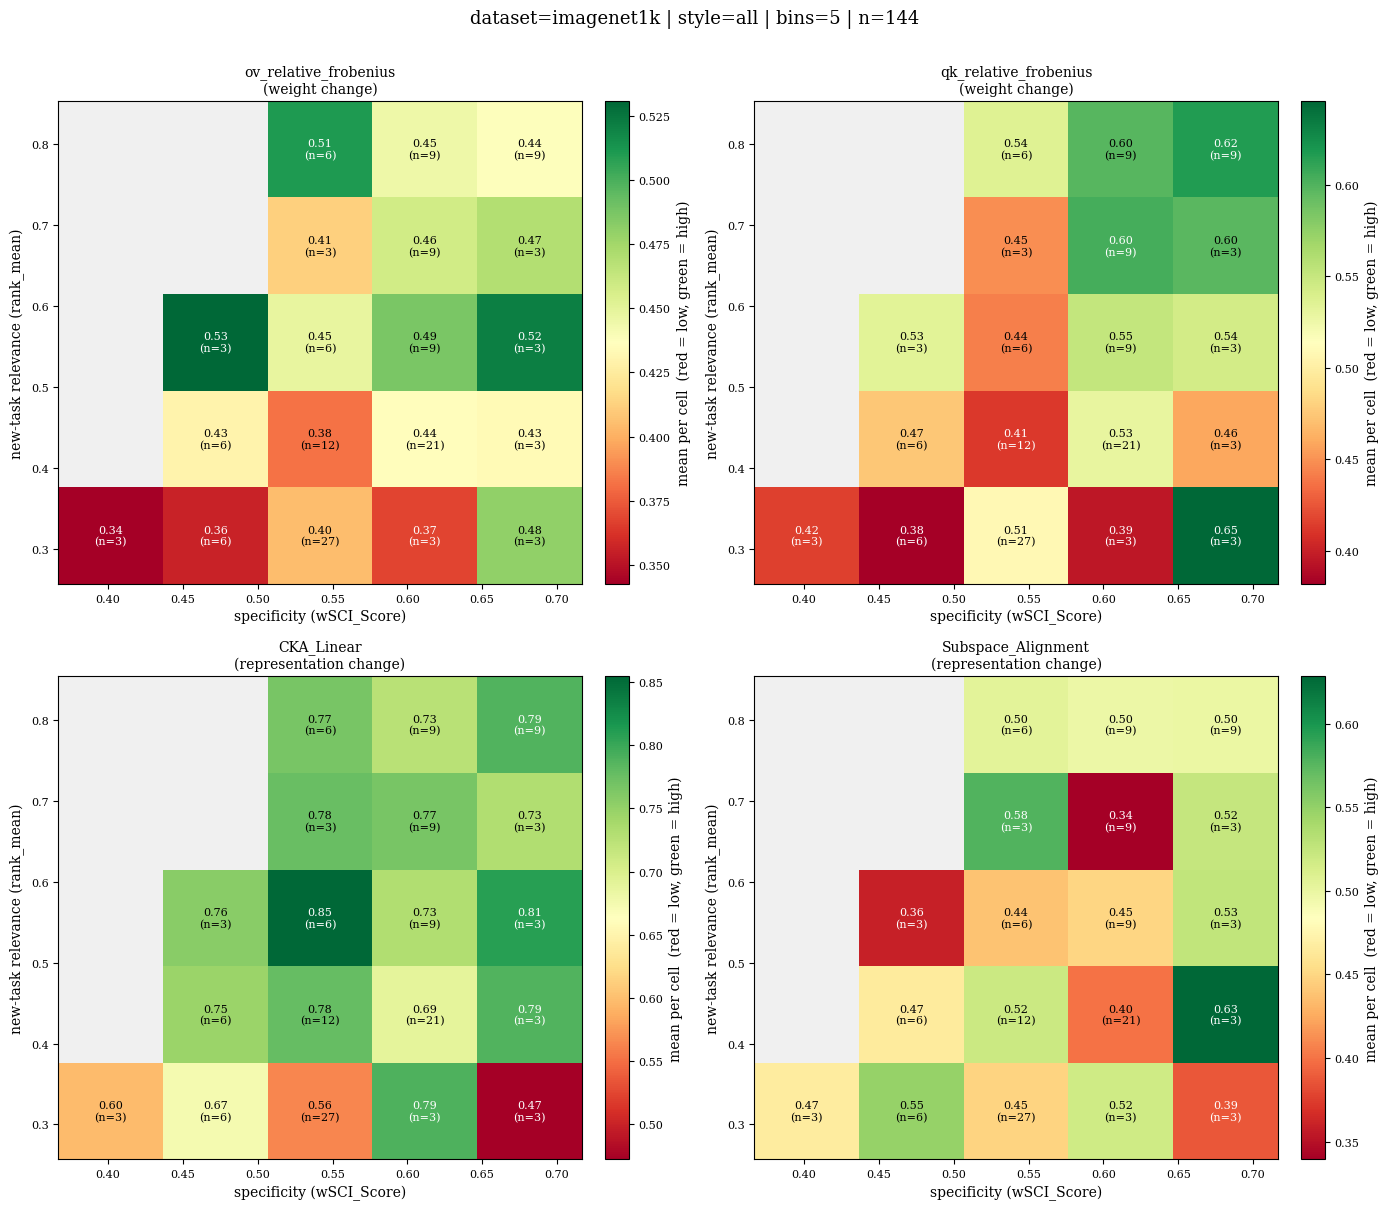

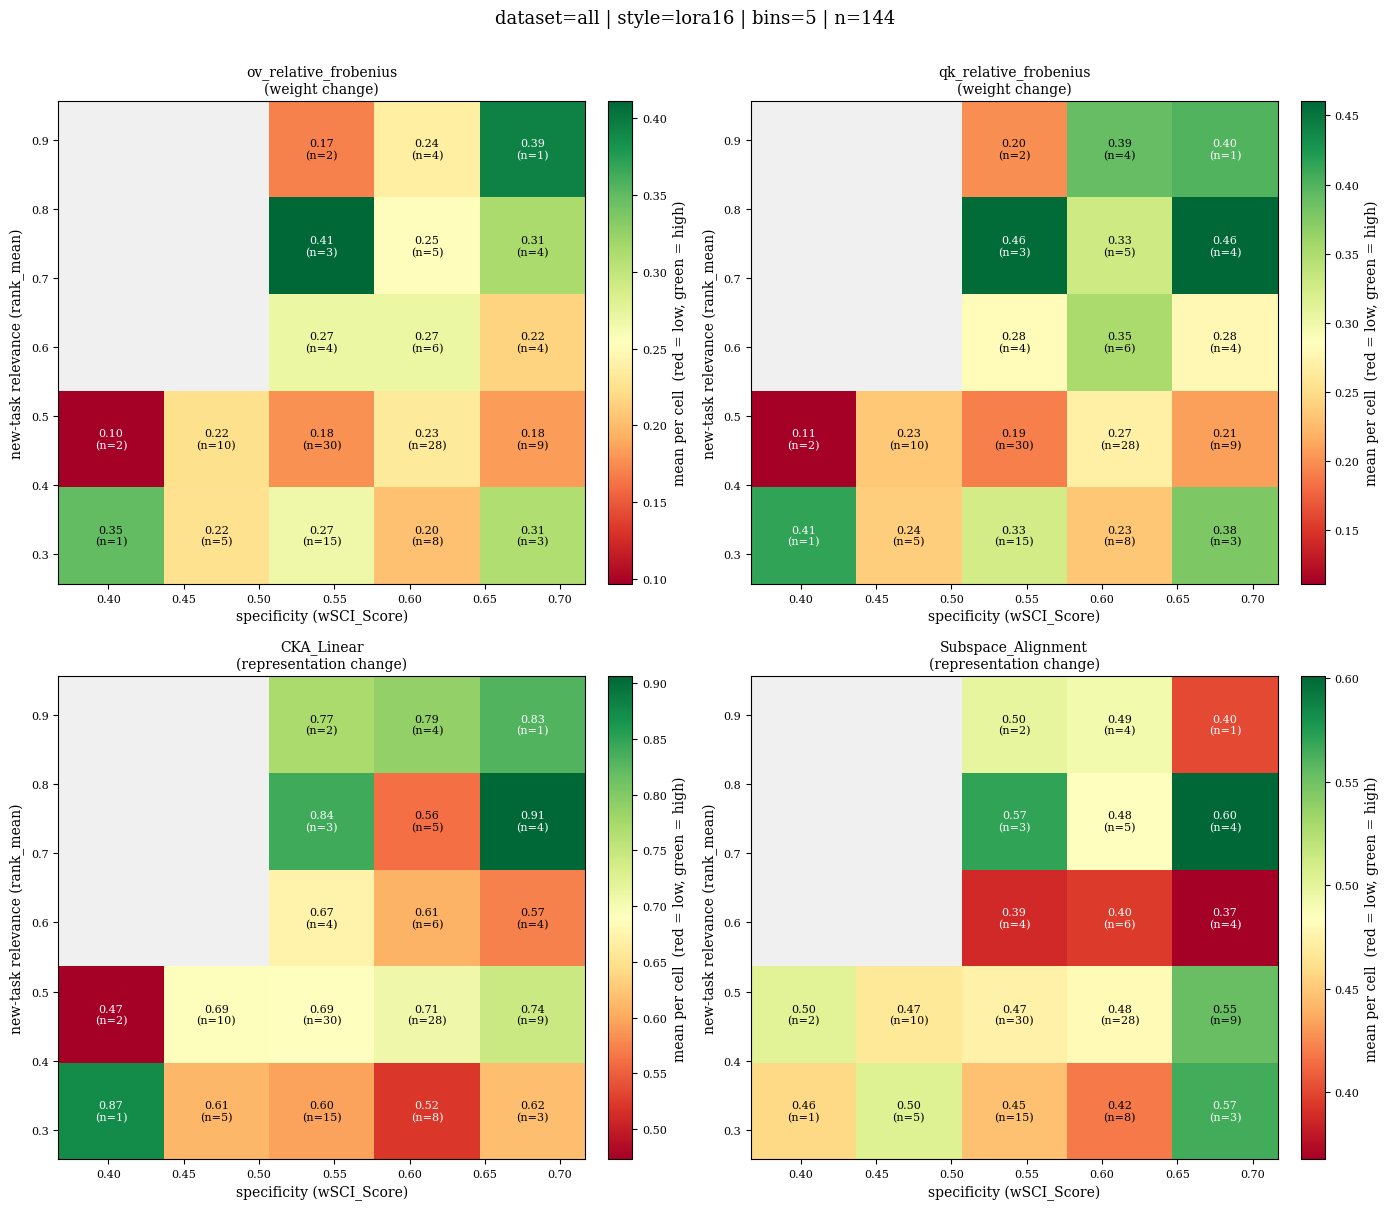

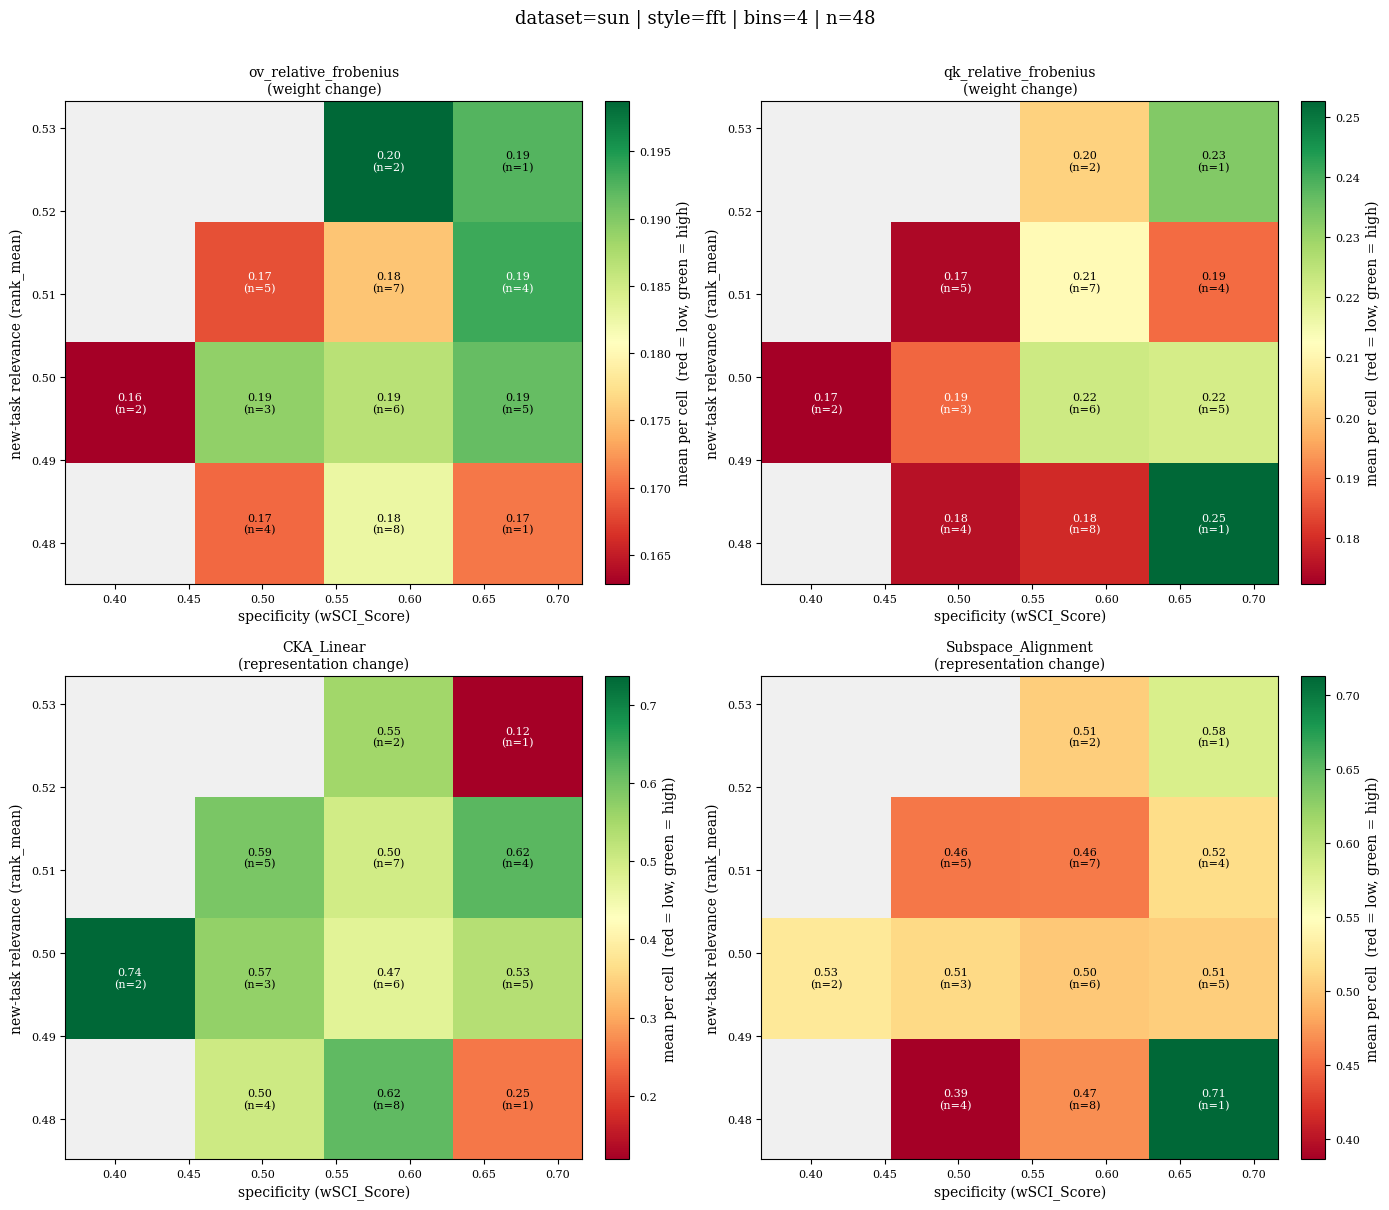

In [27]:
# --- choose metrics here, rerun this small cell to swap. change_metrics can be any length ---
df_grid = build_grid_df(
    spec_metric    = "wSCI_Score",            # x-axis: head specificity
    rele_metric    = "rank_mean",             # y-axis: new-task relevance
    change_metrics = [
        "ov_relative_frobenius",   # weight
        "qk_relative_frobenius",   # weight
        "CKA_Linear",              # representation
        "Subspace_Alignment",      # representation
    ],
)
print(df_grid.shape, "|", {k: df_grid.attrs[k] for k in ("spec_metric", "rele_metric")})
print("metric kinds:", df_grid.attrs["metric_kinds"])
df_grid.head()

grid_change_metrics(df_grid)                                  # pool all
plt.show()

grid_change_metrics(df_grid, dataset="imagenet1k")           # per dataset
plt.show()

grid_change_metrics(df_grid, style="lora16")                 # per method
plt.show()

grid_change_metrics(df_grid, dataset="sun", style="fft", nbins=4)   # both
plt.show()

(432, 8) | {'spec_metric': 'Act_Eff_Dim', 'rele_metric': 'rank_mean', 'weight_metric': 'qk_relative_frobenius', 'rep_metric': 'Subspace_Alignment'}


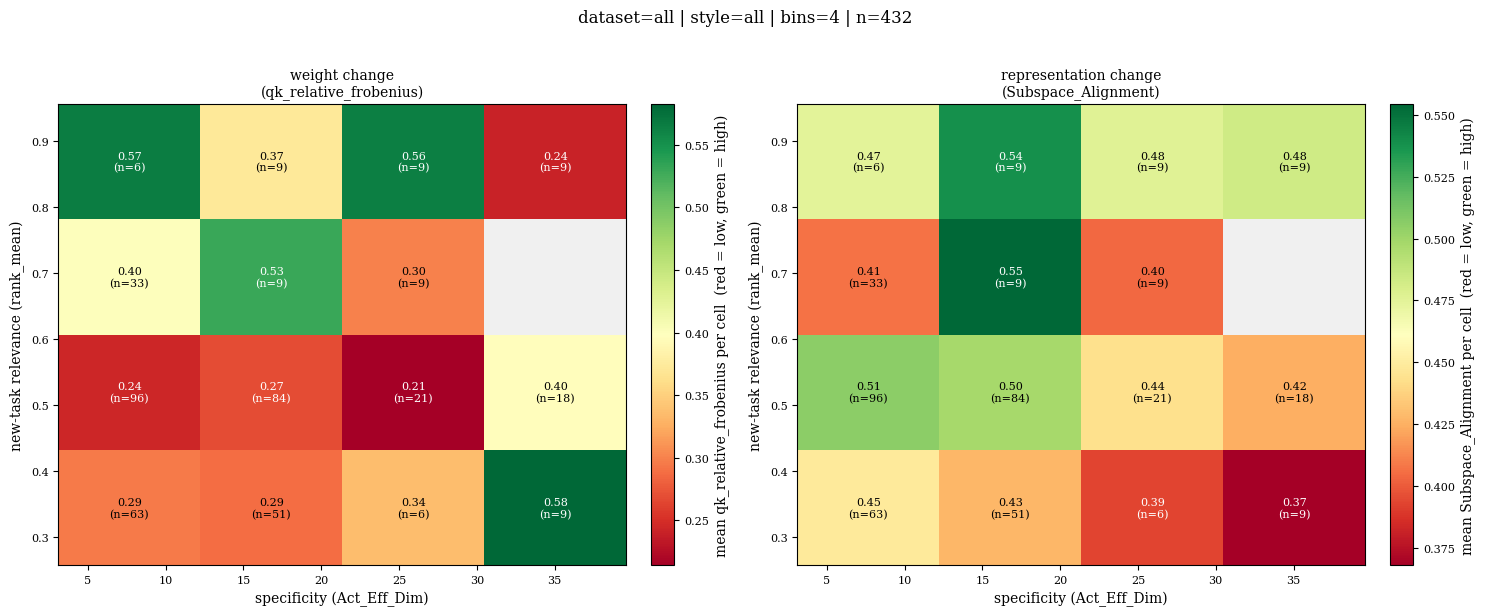

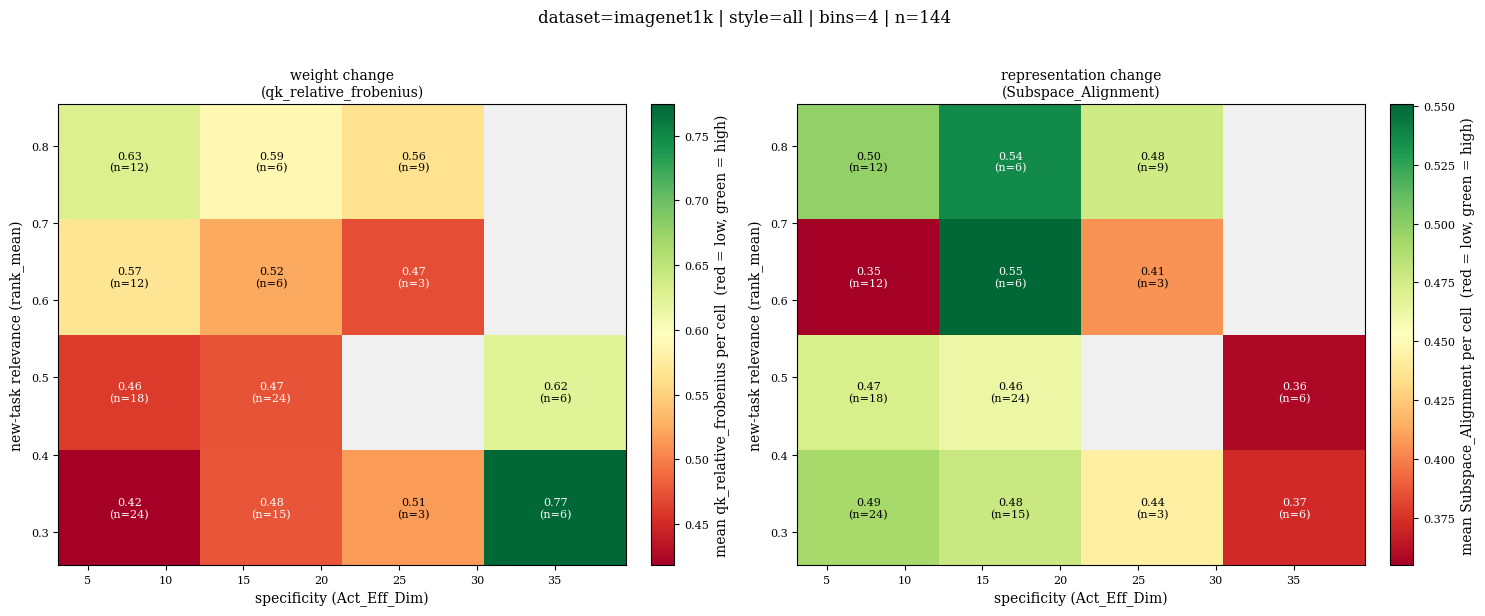

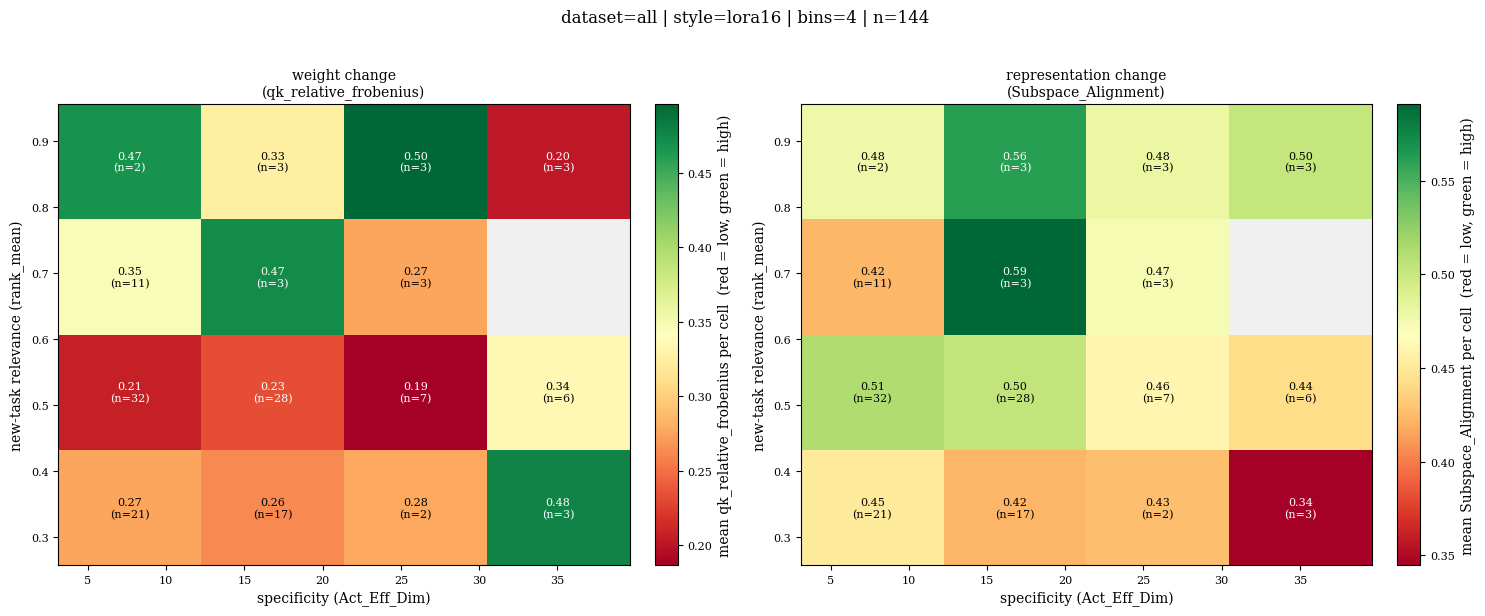

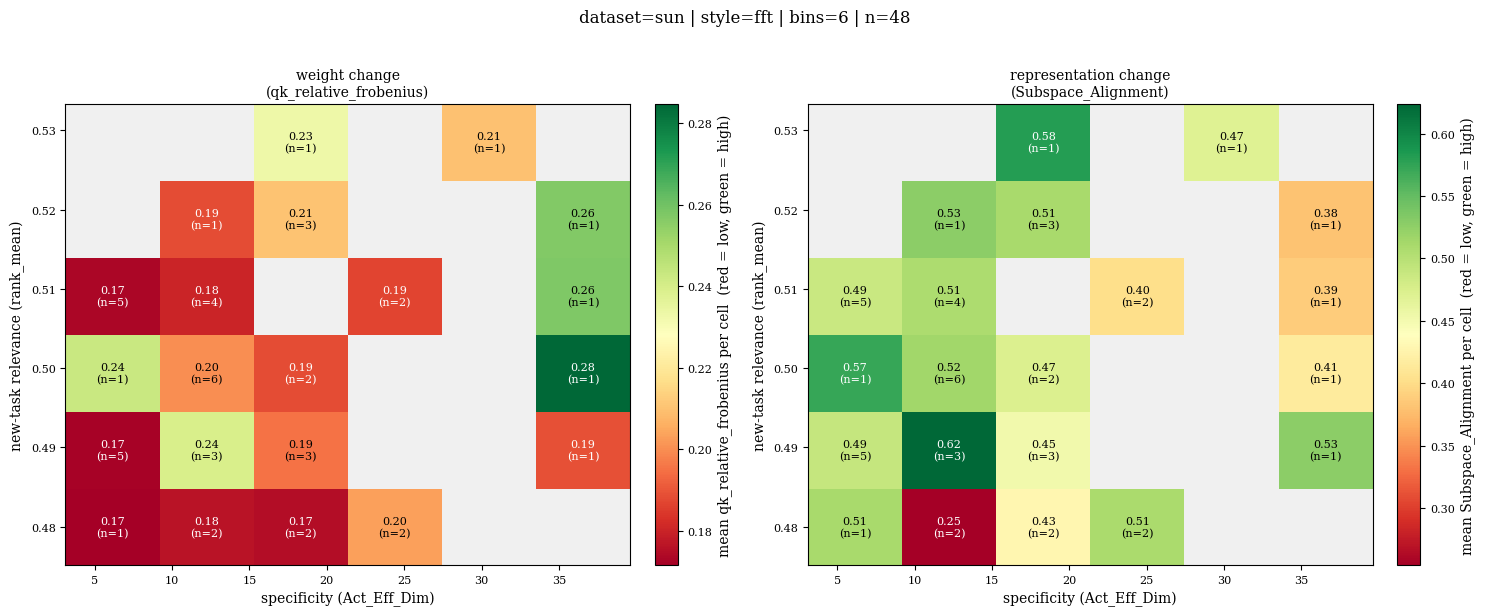

In [23]:
# --- choose metrics here, rerun this small cell to swap ---
df_grid = build_grid_df(
    spec_metric   = "Act_Eff_Dim",             # x-axis: head specificity
    rele_metric   = "rank_mean",              # y-axis: new-task relevance
    weight_metric = "qk_relative_frobenius",  # left panel color (qk_* / ov_*)
    rep_metric    = "Subspace_Alignment",             # right panel color
)
print(df_grid.shape, "|", dict(df_grid.attrs))
df_grid.head()

grid_spec_rele_change(df_grid, nbins=4); plt.show()                                  # pool all
grid_spec_rele_change(df_grid, dataset="imagenet1k", nbins=4); plt.show()            # per dataset
grid_spec_rele_change(df_grid, style="lora16", nbins=4); plt.show()                  # per method
grid_spec_rele_change(df_grid, dataset="sun", style="fft", nbins=6); plt.show()  # both

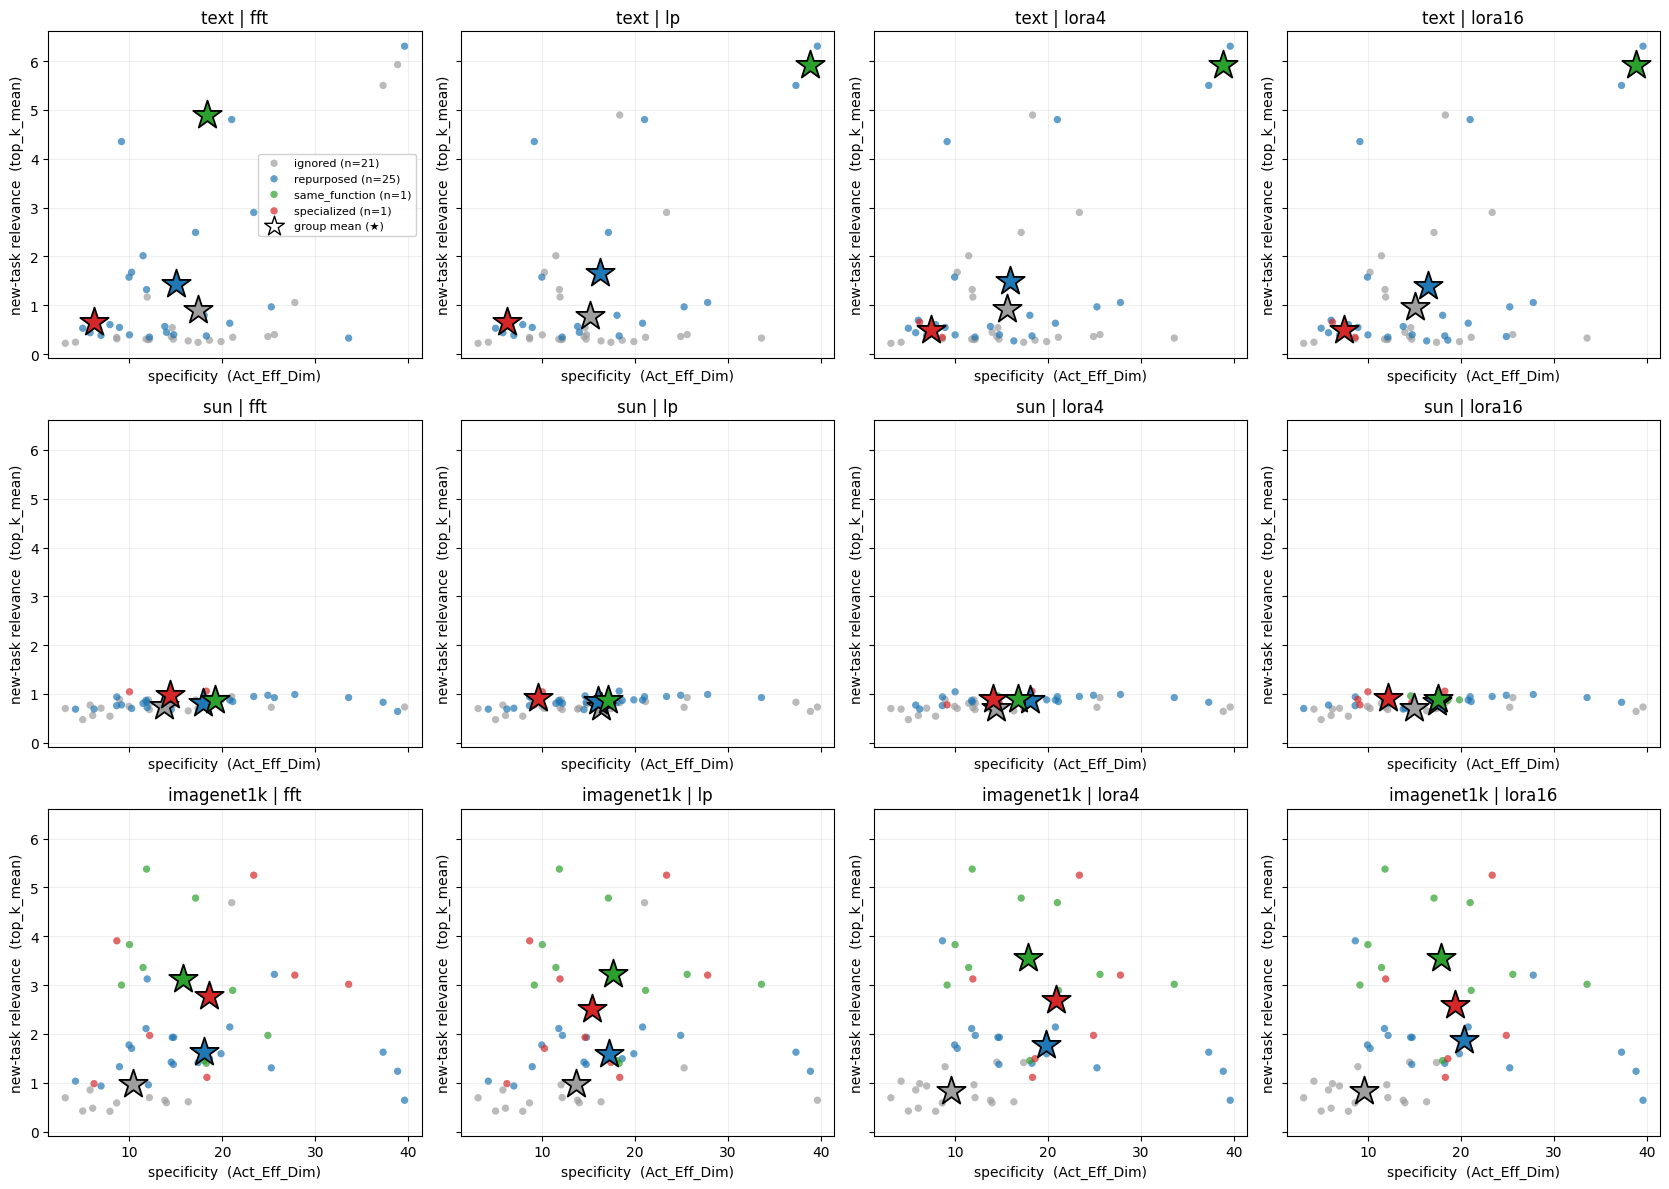

In [9]:
ds_list  = ["text", "sun", "imagenet1k"]
sty_list = ["fft", "lp", "lora4", "lora16"]

fig, axes = plt.subplots(len(ds_list), len(sty_list),
                         figsize=(4.2 * len(sty_list), 4 * len(ds_list)),
                         sharex=True, sharey=True)
for i, ds in enumerate(ds_list):
    for j, st in enumerate(sty_list):
        ax = axes[i, j]
        scatter_spec_vs_rele(df, dataset=ds, style=st, ax=ax, title=f"{ds} | {st}")
        if (i, j) != (0, 0):
            ax.get_legend().remove()
plt.tight_layout(); plt.show()

/tmp/ipykernel_2796214/1675639715.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


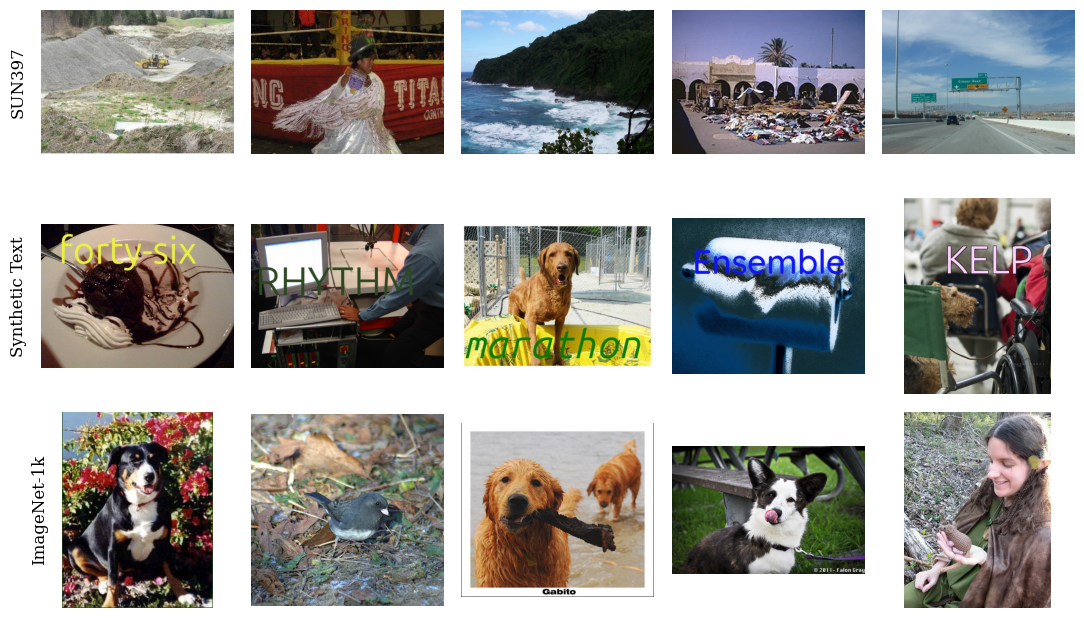

In [45]:
# import random, glob, os
# import matplotlib.pyplot as plt
# from PIL import Image

# datasets = {
#     'SUN397':    '/home/nfm/Desktop/rhome/nfm/sun_dataset_folder_sampled/val',
#     'Synthetic Text': '/home/nfm/Desktop/rhome/nfm/text_overlay_dataset/val',
#     'ImageNet-1k': '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/',
# }

exts = ('*.jpg', '*.jpeg', '*.png', '*.JPEG', '*.JPG')
# random.seed(0)
n = 5

fig, axes = plt.subplots(len(datasets), n, figsize=(n * 2.2, len(datasets) * 2.2))

for row, (name, path) in enumerate(datasets.items()):
    files = [f for e in exts for f in glob.glob(os.path.join(path, '**', e), recursive=True)]
    picks = random.sample(files, n)
    for col, fp in enumerate(picks):
        ax = axes[row, col]
        ax.imshow(Image.open(fp).convert('RGB'))
        ax.axis('off')
    axes[row, 0].set_ylabel(name, fontsize=12, rotation=90, labelpad=10)
    axes[row, 0].axis('on')
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    for s in axes[row, 0].spines.values():
        s.set_visible(False)

plt.tight_layout()
plt.savefig('dataset_samples3.png', dpi=150, bbox_inches='tight')
plt.show()

# skhs

In [14]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real")

# "A" = reference file whose ranking sets the top-weighting ("the first").
# "B" = the file being compared against it ("the second").
PATH_A = BASE / "imagenet1k" / "all_group_scores_fft.json"
PATH_B = BASE / "all_group_scores.json"

OUT_PATH = BASE / "head_similarity_twsas.json"

dA = json.load(open(PATH_A))
dB = json.load(open(PATH_B))
assert list(dA) == list(dB), "head keys differ between files"

In [19]:
def _normalize(vec):
    s = vec.sum()
    return vec / s if s > 0 else vec  # all-zero stays all-zero

def head_similarity(scores_a: dict, scores_b: dict):
    """Top-Weighted Score-Aware Similarity (TWSAS) + diagnostics for one head.

    A = reference (sets ranking & top-weights), B = compared file.
    """
    groups = list(scores_a.keys())                     # 95 groups, aligned
    A = np.array([scores_a[g] for g in groups], float)
    B = np.array([scores_b[g] for g in groups], float)

    # (1) support = groups where the reference A is non-zero
    support = A > 0
    if support.sum() == 0:
        return dict(TWSAS=np.nan, NDCG_A_to_B=np.nan,
                    top5_overlap=np.nan, top10_overlap=np.nan, support_size=0)

    g_idx = np.where(support)[0]
    # (2) normalize within head/file so the different scales are comparable
    pA = _normalize(A[g_idx])
    pB = _normalize(B[g_idx])

    # (2/3) rank groups by reference score (descending) -> DCG position weights
    order = np.argsort(-pA)                              # r = 1 is A's top group
    pA, pB = pA[order], pB[order]
    g_sorted = g_idx[order]
    r = np.arange(1, len(pA) + 1)
    # w = 1.0 / np.log2(r + 1)                             # top counts more
    w = 0.8**(r-1)

    # ---- TWSAS: position-weighted cosine in sqrt-space, in [0, 1] ----
    num = np.sum(w * np.sqrt(pA * pB))
    den = np.sqrt(np.sum(w * pA) * np.sum(w * pB))
    twsas = float(num / den) if den > 0 else 0.0

    # ---- diagnostic 1: NDCG with A-rank as discount, B-score as gain ----
    dcg = np.sum(pB / np.log2(r + 1))                    # gains in A's order
    ideal = np.sort(pB)[::-1]                            # B's best possible order
    idcg = np.sum(ideal / np.log2(r + 1))
    ndcg = float(dcg / idcg) if idcg > 0 else 0.0

    # ---- diagnostic 2: top-k overlap of non-zero groups (Jaccard) ----
    def topk_jaccard(k):
        topA = set(g_sorted[:k])
        b_nonzero_order = g_idx[np.argsort(-B[g_idx])]
        topB = set(b_nonzero_order[: min(k, int((B[g_idx] > 0).sum()))])
        if not topA or not topB:
            return 0.0
        return len(topA & topB) / len(topA | topB)

    return dict(
        TWSAS=twsas,
        NDCG_A_to_B=ndcg,
        top5_overlap=topk_jaccard(5),
        top10_overlap=topk_jaccard(10),
        support_size=int(support.sum()),
    )

In [22]:
results = {}
rows = []
for hk in dA:
    name = dA[hk]["Head_Name"]
    m = head_similarity(dA[hk]["Scores"], dB[hk]["Scores"])
    results[hk] = {"Head_Name": name, **m}
    rows.append({"Head": hk, "Head_Name": name, **m})

json.dump(results, open(OUT_PATH, "w"), indent=2)
print(f"saved -> {OUT_PATH}")

df = pd.DataFrame(rows).round(4)
df.sort_values("NDCG_A_to_B", ascending=False).reset_index(drop=True)

saved -> /home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/head_similarity_twsas.json


,Head,Head_Name,TWSAS,NDCG_A_to_B,top5_overlap,top10_overlap,support_size
0,Head_41,Layer 11 Head 5,0.8585,0.9313,0.6667,0.4286,35
1,Head_20,Layer 9 Head 8,0.8072,0.8696,0.4286,0.2857,20
2,Head_30,Layer 10 Head 6,0.9297,0.8649,0.4286,0.6667,13
3,Head_26,Layer 10 Head 2,0.9123,0.8524,0.2500,0.4615,14
4,Head_42,Layer 11 Head 6,0.8282,0.8421,0.2500,0.2500,27
5,Head_32,Layer 10 Head 8,0.7939,0.7863,0.2500,0.1111,49
6,Head_24,Layer 10 Head 0,0.9250,0.7583,0.6667,0.8000,10
7,Head_28,Layer 10 Head 4,0.8801,0.7304,0.6667,0.3333,31
8,Head_45,Layer 11 Head 9,0.7994,0.7163,0.2500,0.7273,12
9,Head_47,Layer 11 Head 11,0.7903,0.6223,0.0000,0.1765,36


In [42]:
import json, re
from pathlib import Path
import pandas as pd

# PATH = Path("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_fft.json")
PATH = Path("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/text/new_task_rel_org_clip_act.json")
d = json.load(open(PATH))

rows = []
for head_name, v in d.items():
    layer = int(re.search(r"Layer (\d+)", head_name).group(1))
    rows.append({
        "head": head_name,
        "layer": layer,
        "top_k_mean": v["top_k_mean_cos"],
        # "category": v["category"],
    })
df = pd.DataFrame(rows)

In [45]:
# min-max normalize top_k_mean within each layer -> [0, 1]
def minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0.0  # flat layer -> all 0

df["top_k_norm"] = df.groupby("layer")["top_k_mean"].transform(minmax)

for layer, g in df.groupby("layer"):
    print(f"\n=== Layer {layer} ===")
    for _, r in g.iterrows():
        print(f"  {r['head']:<18}  norm={r['top_k_norm']:.4f}  "
            #   f"(raw={r['top_k_mean']:.4f})  [{r['category']}]")
            f"  (raw={r['top_k_mean']:.4f})")

# df


=== Layer 8 ===
  Layer 8 Head 0      norm=0.0323    (raw=0.0035)
  Layer 8 Head 1      norm=0.0114    (raw=0.0017)
  Layer 8 Head 2      norm=0.0000    (raw=0.0007)
  Layer 8 Head 3      norm=0.0292    (raw=0.0032)
  Layer 8 Head 4      norm=0.1101    (raw=0.0102)
  Layer 8 Head 5      norm=0.2069    (raw=0.0185)
  Layer 8 Head 6      norm=0.0108    (raw=0.0016)
  Layer 8 Head 7      norm=0.1415    (raw=0.0129)
  Layer 8 Head 8      norm=1.0000    (raw=0.0869)
  Layer 8 Head 9      norm=0.1354    (raw=0.0124)
  Layer 8 Head 10     norm=0.0164    (raw=0.0021)
  Layer 8 Head 11     norm=0.0998    (raw=0.0093)

=== Layer 9 ===
  Layer 9 Head 0      norm=0.1948    (raw=0.0091)
  Layer 9 Head 1      norm=0.2189    (raw=0.0099)
  Layer 9 Head 2      norm=0.1937    (raw=0.0091)
  Layer 9 Head 3      norm=0.0000    (raw=0.0027)
  Layer 9 Head 4      norm=0.0360    (raw=0.0039)
  Layer 9 Head 5      norm=0.0276    (raw=0.0036)
  Layer 9 Head 6      norm=0.1778    (raw=0.0086)
  Layer 9 Head 7

In [40]:
# PATH = Path("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/changes_fft.json")
PATH = Path("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/new_task_rel_lp.json")
d = json.load(open(PATH))

lp_group = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/imagenet1k/all_group_scores_lp.json", "r"))
org_grp = json.load(open("/home/nfm/Desktop/rhome/nfm/ViT-Prisma/mynotebooks/org_clip_metrics_real/all_group_scores.json", "r"))


idx = 0

head_name, v = list(d.items())[idx]

lp_val = lp_group[list(lp_group.keys())[idx]]['Scores']

# print top 5 keys for this head in lp_val dict by value
top5_keys = sorted(lp_val, key=lp_val.get, reverse=True)[:10]
# print them with their values
print(f"=== Head: {head_name} ===")
for k in top5_keys:
    print(f"  {k:<18}  {lp_val[k]:.4f}")


lp_val = org_grp[list(org_grp.keys())[idx]]['Scores']

# print top 5 keys for this head in lp_val dict by value
top5_keys = sorted(lp_val, key=lp_val.get, reverse=True)[:10]
# print them with their values
print(f"=== Head: {head_name} ===")
for k in top5_keys:
    print(f"  {k:<18}  {lp_val[k]:.4f}")

=== Head: Layer 8 Head 0 ===
  Animals             114.5677
  Dogs & Canines      52.6788
  Reptiles & Amphibians  29.8042
  Tools & Hardware    18.0005
  Insects & Arachnids  14.5056
  Marine & Aquatic Life  11.8485
  Household Objects & Furniture  11.4495
  Musical Instruments  9.1936
  Sports & Athletics  8.5428
  Kitchen & Cooking Equipment  7.5557
=== Head: Layer 8 Head 0 ===
  Locations & Places  29.7373
  Letters, Text & Writing  4.2090
  Plants & Botanical  1.5737
  Natural Landscapes  0.9688
  Trees & Forests     0.8237
  Animals             0.7900
  Sky & Space         0.5698
  Body Parts          0.4941
  Lighting & Light Effects  0.4902
  Fantasy, Magic & Surreal  0.4736
